# 🗑️ Smart Waste Management System with Digital Twin
### Complete Pipeline: EDA → Prediction → Route Optimization → Digital Twin → SimPy DES Simulation → XAI
---

## 📦 Section 0: Install & Import Dependencies

In [5]:
# Install required packages (run once)

!pip install folium plotly dash pandas scikit-learn numpy matplotlib seaborn simpy shap lime --quiet

In [7]:

import sys
!{sys.executable} -m pip install simpy

  Using cached simpy-4.1.1-py3-none-any.whl.metadata (6.1 kB)
Using cached simpy-4.1.1-py3-none-any.whl (27 kB)


In [8]:
import simpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import folium
import warnings
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

print('✅ All dependencies loaded successfully')

✅ All dependencies loaded successfully


## 📊 Section 1: Data Loading & EDA
*(Already completed — kept here for full pipeline flow)*

In [9]:
# Load datasets
df = pd.read_csv('waste_management_dataset.csv')
smart_bin_df = pd.read_csv('Smart_Bin.csv')

# Parse timestamps and extract time features
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.dayofweek
df['Date'] = df['Timestamp'].dt.date

print(f'Dataset shape: {df.shape}')
print(f'Bins: {df["Bin_ID"].nunique()} | Date range: {df["Timestamp"].min()} → {df["Timestamp"].max()}')
df.head()

Dataset shape: (960, 10)
Bins: 20 | Date range: 2026-03-10 06:00:00 → 2026-03-12 05:00:00


,Timestamp,Bin_ID,Latitude,Longitude,Fill_Level,Capacity_kg,Area_Type,Hour,Day,Date
0,2026-03-10 06:00:00,B01,12.937454,77.595071,20,120,Commercial,6,1,2026-03-10
1,2026-03-10 07:00:00,B01,12.937454,77.595071,21,120,Commercial,7,1,2026-03-10
2,2026-03-10 08:00:00,B01,12.937454,77.595071,26,120,Commercial,8,1,2026-03-10
3,2026-03-10 09:00:00,B01,12.937454,77.595071,39,120,Commercial,9,1,2026-03-10
4,2026-03-10 10:00:00,B01,12.937454,77.595071,50,120,Commercial,10,1,2026-03-10


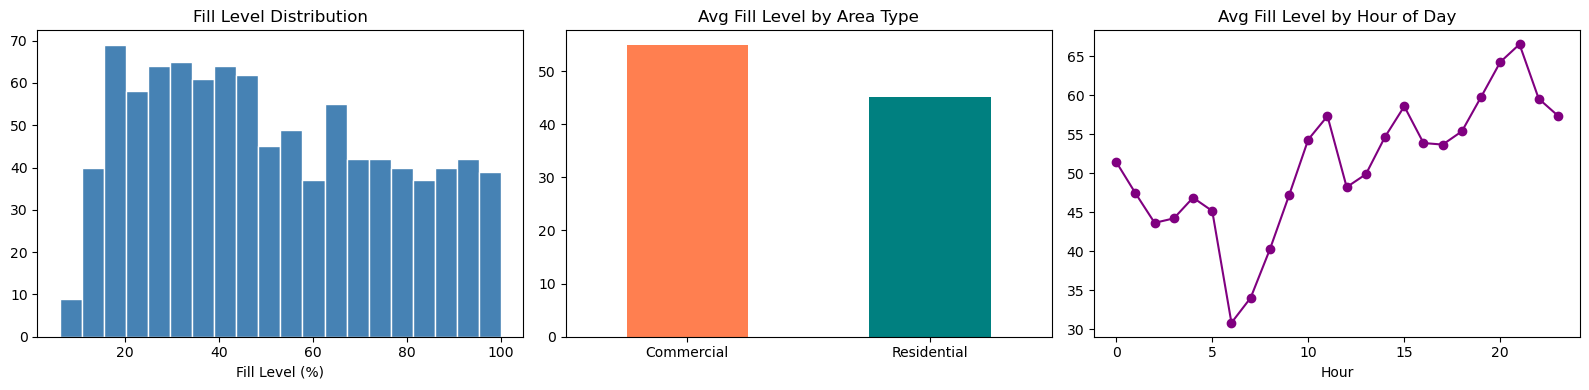

✅ EDA plots saved


In [10]:
# EDA: Fill level distribution across area types
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['Fill_Level'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Fill Level Distribution')
axes[0].set_xlabel('Fill Level (%)')

df.groupby('Area_Type')['Fill_Level'].mean().plot(kind='bar', ax=axes[1], color=['coral', 'teal'])
axes[1].set_title('Avg Fill Level by Area Type')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

df.groupby('Hour')['Fill_Level'].mean().plot(ax=axes[2], color='purple', marker='o')
axes[2].set_title('Avg Fill Level by Hour of Day')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved')

## 🤖 Section 2: Improved Fill Level Prediction (Random Forest)
*(Upgraded from Linear Regression — better accuracy for non-linear patterns)*

In [11]:
# Feature Engineering
le = LabelEncoder()
df['Area_Encoded'] = le.fit_transform(df['Area_Type'])
df['Bin_Encoded'] = le.fit_transform(df['Bin_ID'])

# Create target: fill level at next timestamp
df['Future_Fill'] = df.groupby('Bin_ID')['Fill_Level'].shift(-1)
df_model = df.dropna(subset=['Future_Fill']).copy()

# Features
features = ['Fill_Level', 'Hour', 'Day', 'Capacity_kg', 'Area_Encoded', 'Bin_Encoded']
X = df_model[features]
y = df_model['Future_Fill']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'Random Forest Results:')
print(f'  MAE : {mae:.2f}%')
print(f'  R²  : {r2:.4f}')

Random Forest Results:
  MAE : 2.02%
  R²  : 0.9886


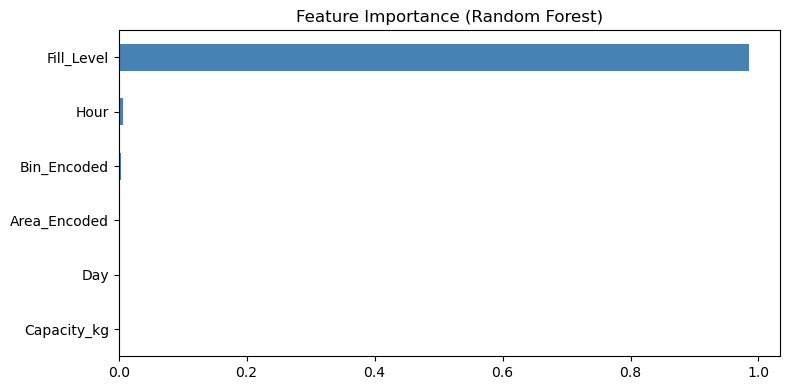

Bins flagged for collection: 256 readings


In [12]:
# Predict on full dataset and flag bins for collection
df_model['Predicted_Fill'] = rf_model.predict(X)
df_model['Collect'] = (df_model['Predicted_Fill'] >= 80) | (df_model['Fill_Level'] >= 70)

# Feature importance plot
plt.figure(figsize=(8, 4))
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Bins flagged for collection: {df_model[df_model["Collect"]].shape[0]} readings')

## 🗺️ Section 3: Route Optimization (Nearest Neighbor + 2-opt)
*(Already completed — kept for pipeline continuity)*

In [13]:
# Get latest state per bin
latest_bins = df_model.sort_values('Timestamp').groupby('Bin_ID').tail(1).copy()
bins_to_collect = latest_bins[latest_bins['Collect'] == True].reset_index(drop=True)

print(f'Total bins: {len(latest_bins)}')
print(f'Bins to collect NOW: {len(bins_to_collect)}')
bins_to_collect[['Bin_ID', 'Fill_Level', 'Predicted_Fill', 'Area_Type']]

Total bins: 20
Bins to collect NOW: 8


,Bin_ID,Fill_Level,Predicted_Fill,Area_Type
0,B01,90,93.20,Commercial
1,B03,83,87.43,Commercial
2,B04,95,14.65,Commercial
3,B05,88,89.43,Commercial
4,B07,96,14.55,Commercial
5,B12,92,94.05,Commercial
6,B14,77,80.04,Commercial
7,B16,89,92.28,Commercial


In [14]:
def distance(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def nearest_neighbor_route(df_bins):
    points = df_bins[['Latitude', 'Longitude']].values.tolist()
    ids    = df_bins['Bin_ID'].tolist()
    route_pts, route_ids = [points.pop(0)], [ids.pop(0)]
    while points:
        last = route_pts[-1]
        idx  = min(range(len(points)), key=lambda i: distance(last, points[i]))
        route_pts.append(points.pop(idx))
        route_ids.append(ids.pop(idx))
    return np.array(route_pts), route_ids

def total_distance(route):
    return sum(np.linalg.norm(route[i] - route[i+1]) for i in range(len(route)-1))

def two_opt(route):
    best, improved = route.copy(), True
    while improved:
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+1, len(route)):
                if j - i == 1: continue
                new_route = route.copy()
                new_route[i:j] = route[j-1:i-1:-1]
                if total_distance(new_route) < total_distance(best):
                    best, improved = new_route, True
        route = best
    return best

if len(bins_to_collect) >= 2:
    route_pts, route_ids = nearest_neighbor_route(bins_to_collect)
    optimized_route = two_opt(route_pts)
    dist_before = total_distance(route_pts)
    dist_after  = total_distance(optimized_route)
    print(f'Distance before 2-opt: {dist_before:.6f}')
    print(f'Distance after  2-opt: {dist_after:.6f}')
    print(f'Improvement: {((dist_before - dist_after)/dist_before)*100:.1f}%')
else:
    print('Not enough bins to optimize route')

Distance before 2-opt: 0.250580
Distance after  2-opt: 0.220807
Improvement: 11.9%


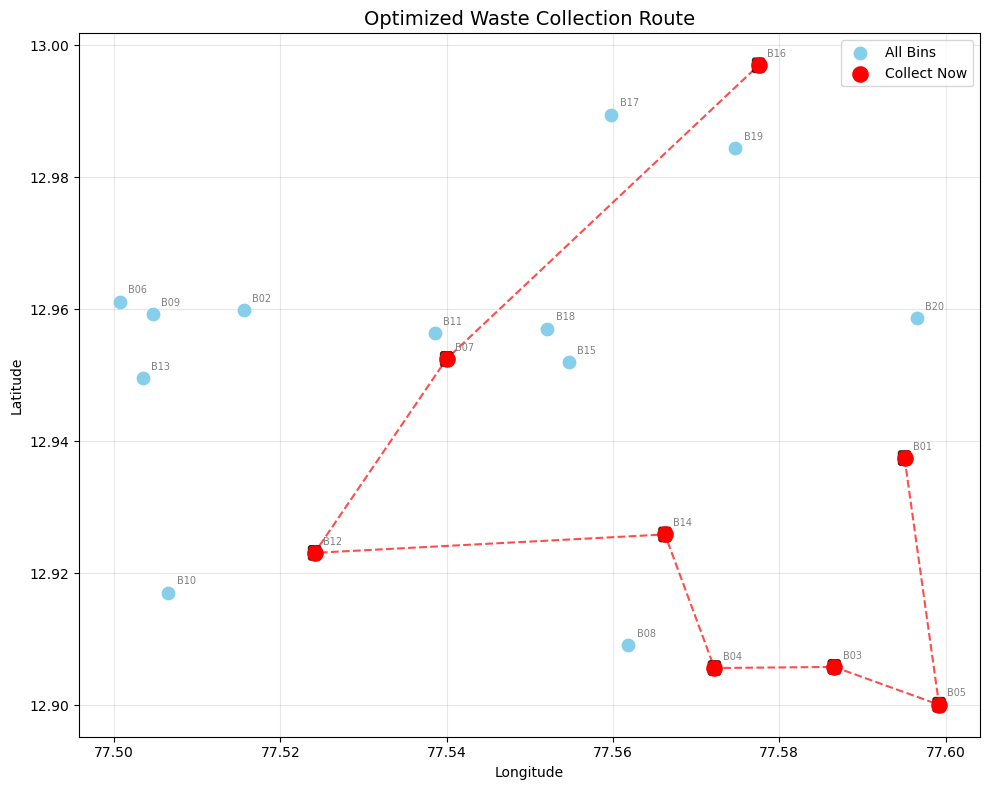

In [15]:
# Static route plot
plt.figure(figsize=(10, 8))
plt.scatter(latest_bins['Longitude'], latest_bins['Latitude'],
            c='skyblue', s=80, zorder=3, label='All Bins')
plt.scatter(bins_to_collect['Longitude'], bins_to_collect['Latitude'],
            c='red', s=120, zorder=4, label='Collect Now')

if len(bins_to_collect) >= 2:
    plt.plot(optimized_route[:,1], optimized_route[:,0],
             'r--', linewidth=1.5, alpha=0.7, zorder=2)
    for i, (lat, lon) in enumerate(optimized_route):
        plt.annotate(str(i+1), (lon, lat), fontsize=8,
                     ha='center', va='center', fontweight='bold', color='white',
                     bbox=dict(boxstyle='round,pad=0.2', fc='red', alpha=0.8))

for _, row in latest_bins.iterrows():
    plt.annotate(row['Bin_ID'], (row['Longitude'], row['Latitude']),
                 textcoords='offset points', xytext=(6,6), fontsize=7, color='gray')

plt.title('Optimized Waste Collection Route', fontsize=14)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optimized_route.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ Section 4: Interactive Map with Folium

In [16]:
def fill_color(fill_level):
    if fill_level >= 80: return 'red'
    elif fill_level >= 50: return 'orange'
    else: return 'green'

m = folium.Map(
    location=[latest_bins['Latitude'].mean(), latest_bins['Longitude'].mean()],
    zoom_start=13,
    tiles='CartoDB positron'
)

for _, row in latest_bins.iterrows():
    color = fill_color(row['Fill_Level'])
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=10,
        color=color, fill=True, fill_color=color, fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['Bin_ID']}</b><br>"
            f"Fill: {row['Fill_Level']}%<br>"
            f"Predicted: {row['Predicted_Fill']:.1f}%<br>"
            f"Area: {row['Area_Type']}<br>"
            f"Collect: {'✅ YES' if row['Collect'] else '⏳ No'}",
            max_width=200
        ),
        tooltip=f"{row['Bin_ID']}: {row['Fill_Level']}%"
    ).add_to(m)

if len(bins_to_collect) >= 2:
    route_coords = [[lat, lon] for lat, lon in optimized_route]
    folium.PolyLine(route_coords, color='darkred', weight=3,
                    opacity=0.8, dash_array='10',
                    tooltip='Optimized Collection Route').add_to(m)
    for i, (lat, lon) in enumerate(optimized_route):
        folium.Marker(
            [lat, lon],
            icon=folium.DivIcon(
                html=f'<div style="font-size:11px;color:white;background:darkred;'
                     f'border-radius:50%;width:22px;height:22px;text-align:center;'
                     f'line-height:22px;font-weight:bold;">{i+1}</div>'
            )
        ).add_to(m)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
            padding:10px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
  <b>Fill Level</b><br>
  <span style="color:green">●</span> &lt; 50% (OK)<br>
  <span style="color:orange">●</span> 50–79% (Monitor)<br>
  <span style="color:red">●</span> ≥ 80% (Collect!)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save('interactive_route_map.html')
print('✅ Interactive map saved: interactive_route_map.html')
m

✅ Interactive map saved: interactive_route_map.html


## 🤖 Section 5: Smart Bin Classification (from Smart_Bin.csv)
### Predicting whether a bin will be emptied or not

In [17]:
sb = pd.read_csv('Smart_Bin.csv')
print(sb.head())
print('\nClass distribution:')
print(sb['Class'].value_counts())

          Class  FL_B  FL_A   VS  FL_B_3  FL_A_3  FL_B_12  FL_A_12  \
0      Emptying  85.3  34.4  6.0    75.9    54.7     83.3     39.8   
1      Emptying  96.2  51.7  8.0    83.3    33.9     85.0     57.4   
2  Non Emptying  50.9  63.5  5.0    30.8    55.7     51.7     68.5   
3      Emptying  83.1  33.9  6.0    91.8    61.1     84.6     43.6   
4  Non Emptying  73.5  32.2  3.0    68.0    30.5     62.4     53.0   

         Container Type Recyclable fraction  
0           Silvertop-a               Mixed  
1  BIM-3 FTI bottentomd      Non Recyclable  
2  BIM-3 FTI bottentomd          Recyclable  
3           Lindstrom-a               Mixed  
4           Lindstrom-a      Non Recyclable  

Class distribution:
Class
Non Emptying    2364
Emptying        2274
Name: count, dtype: int64


In [18]:
sb_encoded = sb.copy()
for col in ['Container Type', 'Recyclable fraction']:
    sb_encoded[col] = LabelEncoder().fit_transform(sb_encoded[col])

sb_encoded['Class_Label'] = (sb_encoded['Class'] == 'Emptying').astype(int)

features_sb = ['FL_B', 'FL_A', 'VS', 'FL_B_3', 'FL_A_3', 'FL_B_12', 'FL_A_12',
               'Container Type', 'Recyclable fraction']
X_sb = sb_encoded[features_sb]
y_sb = sb_encoded['Class_Label']
X_sb = X_sb.fillna(X_sb.mean())

X_tr, X_te, y_tr, y_te = train_test_split(X_sb, y_sb, test_size=0.2, random_state=42)

clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf.fit(X_tr, y_tr)
y_pred_sb = clf.predict(X_te)

print(classification_report(y_te, y_pred_sb, target_names=['Non Emptying', 'Emptying']))

              precision    recall  f1-score   support

Non Emptying       0.93      0.90      0.92       471
    Emptying       0.90      0.93      0.92       457

    accuracy                           0.92       928
   macro avg       0.92      0.92      0.92       928
weighted avg       0.92      0.92      0.92       928



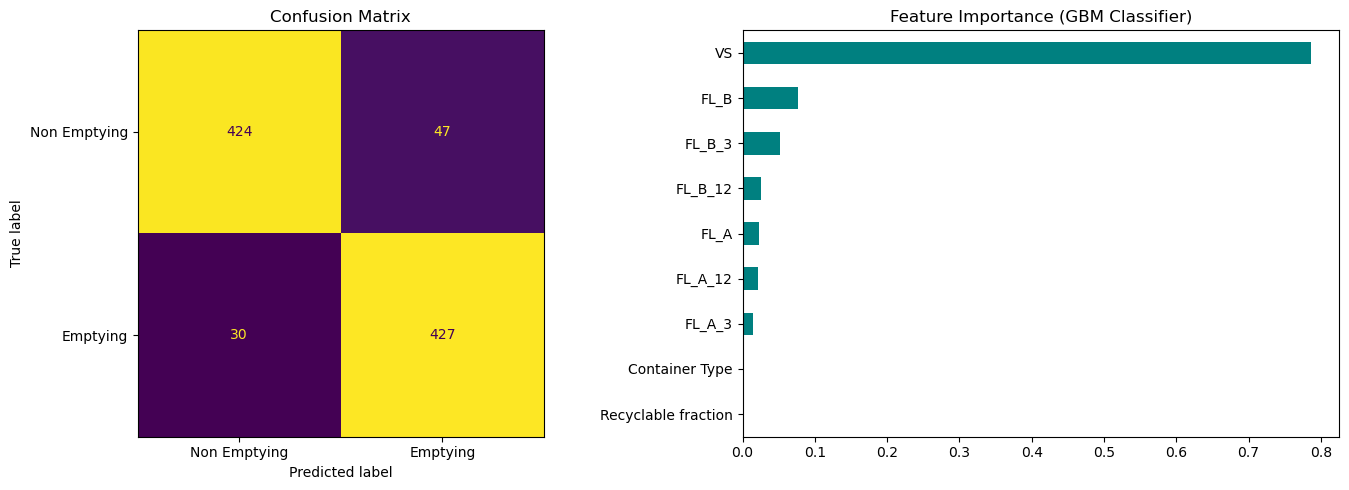

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_te, y_pred_sb)
ConfusionMatrixDisplay(cm, display_labels=['Non Emptying', 'Emptying']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

imp = pd.Series(clf.feature_importances_, index=features_sb).sort_values()
imp.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Feature Importance (GBM Classifier)')

plt.tight_layout()
plt.savefig('classifier_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌐 Section 6: Digital Twin Integration
### Real-time simulation of bin states with anomaly detection, alerts & live dashboard

A **Digital Twin** creates a virtual replica of each physical bin, continuously updated with simulated sensor data. It enables:
- 🔄 Real-time state synchronization  
- ⚠️ Anomaly detection (sudden fill spikes)
- 📡 Alert system (overflow warnings)
- 📊 Live monitoring dashboard
- 🔮 Predictive maintenance simulation

In [20]:
# ── 6.1  Digital Twin Core Class ──────────────────────────────────────────────

class SmartBinTwin:
    ALERT_THRESHOLDS = {'critical': 90, 'warning': 75, 'monitor': 50}

    def __init__(self, bin_id, latitude, longitude, capacity_kg, area_type):
        self.bin_id       = bin_id
        self.latitude     = latitude
        self.longitude    = longitude
        self.capacity_kg  = capacity_kg
        self.area_type    = area_type
        self.fill_level      = 0.0
        self.predicted_fill  = 0.0
        self.last_updated    = None
        self.collection_due  = False
        self.anomaly_flag    = False
        self.alert_level     = 'normal'
        self.history   = []
        self.alerts    = []
        self._fill_rate = random.uniform(3.0, 8.0)

    def update(self, timestamp, new_fill_level):
        prev_fill = self.fill_level
        self.fill_level   = new_fill_level
        self.last_updated = timestamp
        spike = abs(new_fill_level - prev_fill)
        self.anomaly_flag = spike > 30 and prev_fill > 0
        self.predicted_fill = min(100, new_fill_level + self._fill_rate * 3)
        self.collection_due = (self.predicted_fill >= 80) or (new_fill_level >= 70)
        if new_fill_level >= self.ALERT_THRESHOLDS['critical']:
            self.alert_level = 'critical'
        elif new_fill_level >= self.ALERT_THRESHOLDS['warning']:
            self.alert_level = 'warning'
        elif new_fill_level >= self.ALERT_THRESHOLDS['monitor']:
            self.alert_level = 'monitor'
        else:
            self.alert_level = 'normal'
        record = {'timestamp': timestamp, 'fill_level': new_fill_level,
                  'predicted': self.predicted_fill, 'anomaly': self.anomaly_flag,
                  'alert': self.alert_level}
        self.history.append(record)
        if self.alert_level in ('warning', 'critical') or self.anomaly_flag:
            self.alerts.append({'time': timestamp, 'bin_id': self.bin_id,
                                'level': self.alert_level if not self.anomaly_flag else 'anomaly',
                                'fill': new_fill_level,
                                'message': f'[{self.alert_level.upper()}] {self.bin_id} fill={new_fill_level}%'
                                           + (' ⚠️ ANOMALY DETECTED' if self.anomaly_flag else '')})

    def simulate_tick(self, timestamp, noise=2.0):
        increment = self._fill_rate + random.gauss(0, noise)
        new_fill  = min(100, max(0, self.fill_level + increment))
        if random.random() < 0.03:
            new_fill = min(100, self.fill_level + random.uniform(30, 45))
        self.update(timestamp, round(new_fill, 1))

    def collect(self, timestamp):
        self.update(timestamp, 5.0)
        self.collection_due = False
        print(f'  🚛 {self.bin_id} collected at {timestamp}')

    def status_summary(self):
        return {'Bin': self.bin_id, 'Fill%': self.fill_level,
                'Predicted3h%': round(self.predicted_fill, 1),
                'Alert': self.alert_level, 'Anomaly': self.anomaly_flag,
                'CollectDue': self.collection_due, 'LastUpdated': self.last_updated}

print('✅ SmartBinTwin class defined')

✅ SmartBinTwin class defined


In [21]:
# ── 6.2  Digital Twin Fleet Manager ──────────────────────────────────────────

class DigitalTwinFleet:
    def __init__(self):
        self.twins       = {}
        self.global_log  = []
        self.sim_time    = None

    def register_bin(self, twin: SmartBinTwin):
        self.twins[twin.bin_id] = twin

    def initialize_from_dataset(self, df_latest):
        for _, row in df_latest.iterrows():
            t = SmartBinTwin(bin_id=row['Bin_ID'], latitude=row['Latitude'],
                             longitude=row['Longitude'], capacity_kg=row['Capacity_kg'],
                             area_type=row['Area_Type'])
            t.update(row['Timestamp'], row['Fill_Level'])
            self.register_bin(t)
        self.sim_time = df_latest['Timestamp'].max()
        print(f'✅ Fleet initialized with {len(self.twins)} bin twins')
        print(f'   Simulation clock: {self.sim_time}')

    def tick(self, hours=1):
        for _ in range(hours):
            self.sim_time += timedelta(hours=1)
            for twin in self.twins.values():
                twin.simulate_tick(self.sim_time)
                if twin.fill_level >= 95:
                    twin.collect(self.sim_time)
            new_alerts = [a for twin in self.twins.values()
                          for a in twin.alerts if a['time'] == self.sim_time]
            self.global_log.extend(new_alerts)

    def fleet_status(self):
        return pd.DataFrame([t.status_summary() for t in self.twins.values()])

    def bins_needing_collection(self):
        return [t for t in self.twins.values() if t.collection_due]

print('✅ DigitalTwinFleet class defined')

✅ DigitalTwinFleet class defined


In [22]:
# ── 6.3  Instantiate & run the Digital Twin simulation ───────────────────────

seed_data = df_model.sort_values('Timestamp').groupby('Bin_ID').tail(1).reset_index(drop=True)

fleet = DigitalTwinFleet()
fleet.initialize_from_dataset(seed_data)

print('\n📊 Initial fleet status:')
status0 = fleet.fleet_status()
print(status0[['Bin', 'Fill%', 'Predicted3h%', 'Alert', 'CollectDue']].to_string(index=False))

✅ Fleet initialized with 20 bin twins
   Simulation clock: 2026-03-12 04:00:00

📊 Initial fleet status:
Bin  Fill%  Predicted3h%    Alert  CollectDue
B10     17          35.6   normal       False
B18     19          28.4   normal       False
B01     90         100.0 critical        True
B02     35          47.3   normal       False
B03     83         100.0  warning        True
B04     95         100.0 critical        True
B05     88         100.0  warning        True
B06     35          45.3   normal       False
B07     96         100.0 critical        True
B19     25          34.4   normal       False
B08     24          36.3   normal       False
B11     37          53.6   normal       False
B12     92         100.0 critical        True
B13     38          50.0   normal       False
B14     77          95.7  warning        True
B15     27          44.2   normal       False
B16     89         100.0  warning        True
B17     22          39.8   normal       False
B09     26          47

In [23]:
# ── 6.4  Run 24-hour simulation ───────────────────────────────────────────────
print('🕐 Running 24-hour Digital Twin simulation...\n')

hourly_snapshots = []
for hour in range(24):
    fleet.tick(hours=1)
    snap = fleet.fleet_status().copy()
    snap['sim_hour'] = hour + 1
    hourly_snapshots.append(snap)

sim_df = pd.concat(hourly_snapshots, ignore_index=True)

print(f'\n✅ Simulation complete!')
print(f'   Total alerts raised : {len(fleet.global_log)}')
print(f'   Bins needing pickup : {len(fleet.bins_needing_collection())}')
print('\n📊 Final fleet status:')
fleet.fleet_status()[['Bin','Fill%','Predicted3h%','Alert','CollectDue']]

🕐 Running 24-hour Digital Twin simulation...

  🚛 B01 collected at 2026-03-12 05:00:00
  🚛 B04 collected at 2026-03-12 05:00:00
  🚛 B07 collected at 2026-03-12 05:00:00
  🚛 B12 collected at 2026-03-12 05:00:00
  🚛 B03 collected at 2026-03-12 06:00:00
  🚛 B05 collected at 2026-03-12 06:00:00
  🚛 B16 collected at 2026-03-12 06:00:00
  🚛 B14 collected at 2026-03-12 07:00:00
  🚛 B11 collected at 2026-03-12 12:00:00
  🚛 B12 collected at 2026-03-12 13:00:00
  🚛 B04 collected at 2026-03-12 14:00:00
  🚛 B15 collected at 2026-03-12 14:00:00
  🚛 B09 collected at 2026-03-12 14:00:00
  🚛 B10 collected at 2026-03-12 15:00:00
  🚛 B06 collected at 2026-03-12 16:00:00
  🚛 B17 collected at 2026-03-12 16:00:00
  🚛 B03 collected at 2026-03-12 17:00:00
  🚛 B02 collected at 2026-03-12 18:00:00
  🚛 B19 collected at 2026-03-12 18:00:00
  🚛 B13 collected at 2026-03-12 18:00:00
  🚛 B20 collected at 2026-03-12 18:00:00
  🚛 B05 collected at 2026-03-12 19:00:00
  🚛 B07 collected at 2026-03-12 22:00:00
  🚛 B08 col

,Bin,Fill%,Predicted3h%,Alert,CollectDue
0,B10,91.7,100.0,critical,True
1,B18,5.0,14.4,normal,False
2,B01,5.0,18.1,normal,False
3,B02,86.3,98.6,warning,True
4,B03,22.0,42.0,normal,False
5,B04,94.8,100.0,critical,True
6,B05,83.0,100.0,warning,True
7,B06,38.9,49.2,normal,False
8,B07,35.6,50.9,normal,False
9,B19,41.4,50.8,normal,False


In [24]:
# ── 6.5  Alert log ────────────────────────────────────────────────────────────
if fleet.global_log:
    alert_df = pd.DataFrame(fleet.global_log)
    print(f'🚨 Alert Log ({len(alert_df)} events):')
    print(alert_df[['time','bin_id','level','fill','message']].to_string(index=False))
else:
    print('No alerts raised during simulation.')

🚨 Alert Log (136 events):
               time bin_id    level  fill                                       message
2026-03-12 05:00:00    B01 critical  96.1                     [CRITICAL] B01 fill=96.1%
2026-03-12 05:00:00    B01  anomaly   5.0    [NORMAL] B01 fill=5.0% ⚠️ ANOMALY DETECTED
2026-03-12 05:00:00    B03 critical  91.2                     [CRITICAL] B03 fill=91.2%
2026-03-12 05:00:00    B04 critical  99.2                     [CRITICAL] B04 fill=99.2%
2026-03-12 05:00:00    B04  anomaly   5.0    [NORMAL] B04 fill=5.0% ⚠️ ANOMALY DETECTED
2026-03-12 05:00:00    B05 critical  90.2                     [CRITICAL] B05 fill=90.2%
2026-03-12 05:00:00    B07 critical 100.0                      [CRITICAL] B07 fill=100%
2026-03-12 05:00:00    B07  anomaly   5.0    [NORMAL] B07 fill=5.0% ⚠️ ANOMALY DETECTED
2026-03-12 05:00:00    B12 critical  96.4                     [CRITICAL] B12 fill=96.4%
2026-03-12 05:00:00    B12  anomaly   5.0    [NORMAL] B12 fill=5.0% ⚠️ ANOMALY DETECTED
2026-0

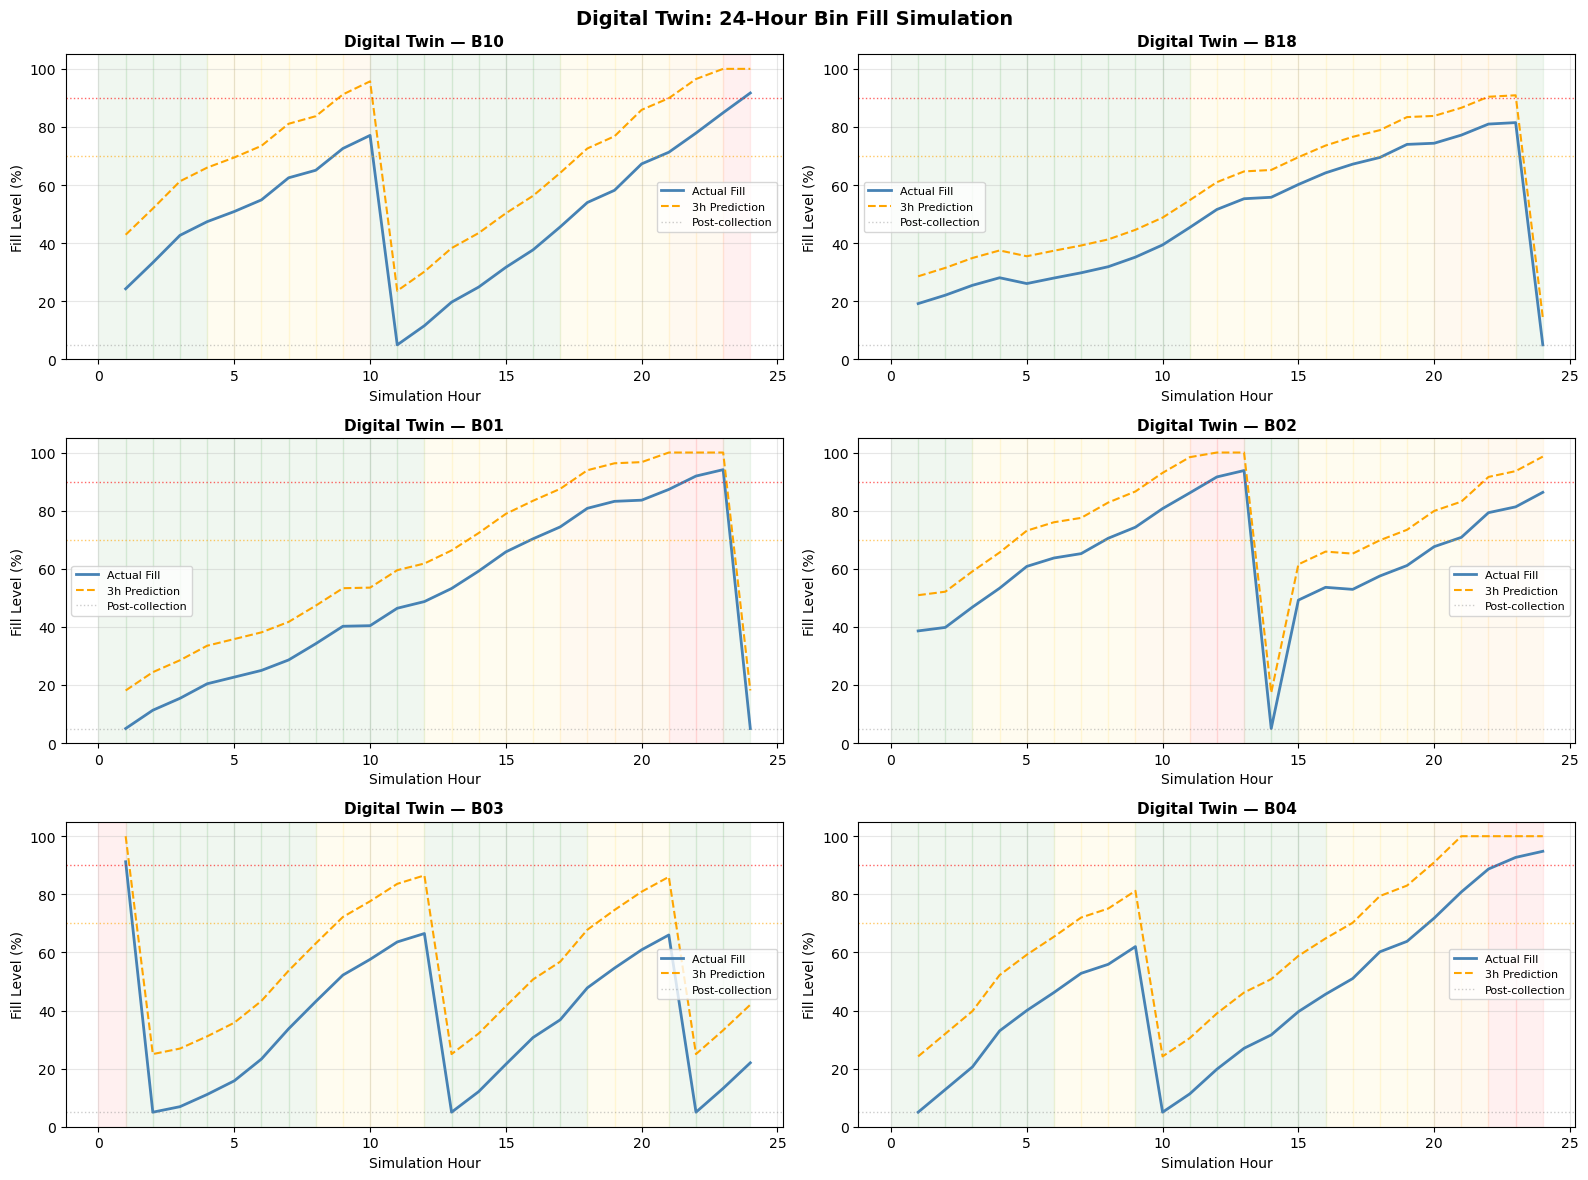

✅ Dashboard saved: digital_twin_dashboard.png


In [25]:
# ── 6.6  Digital Twin Monitoring Dashboard ───────────────────────────────────

sample_bins = sim_df['Bin'].unique()[:6]
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()
alert_palette = {'normal': 'green', 'monitor': 'gold',
                 'warning': 'orange', 'critical': 'red', 'anomaly': 'purple'}

for ax, bin_id in zip(axes, sample_bins):
    bdata = sim_df[sim_df['Bin'] == bin_id]
    ax.plot(bdata['sim_hour'], bdata['Fill%'], label='Actual Fill', color='steelblue', linewidth=2)
    ax.plot(bdata['sim_hour'], bdata['Predicted3h%'], label='3h Prediction', color='orange', linewidth=1.5, linestyle='--')
    for _, row in bdata.iterrows():
        c = alert_palette.get(row['Alert'], 'white')
        ax.axvspan(row['sim_hour']-1, row['sim_hour'], alpha=0.06, color=c)
    ax.axhline(70, color='orange', linestyle=':', alpha=0.6, linewidth=1)
    ax.axhline(90, color='red',    linestyle=':', alpha=0.6, linewidth=1)
    ax.axhline(5,  color='gray',   linestyle=':', alpha=0.4, linewidth=1, label='Post-collection')
    ax.set_title(f'Digital Twin — {bin_id}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Simulation Hour')
    ax.set_ylabel('Fill Level (%)')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Digital Twin: 24-Hour Bin Fill Simulation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('digital_twin_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved: digital_twin_dashboard.png')

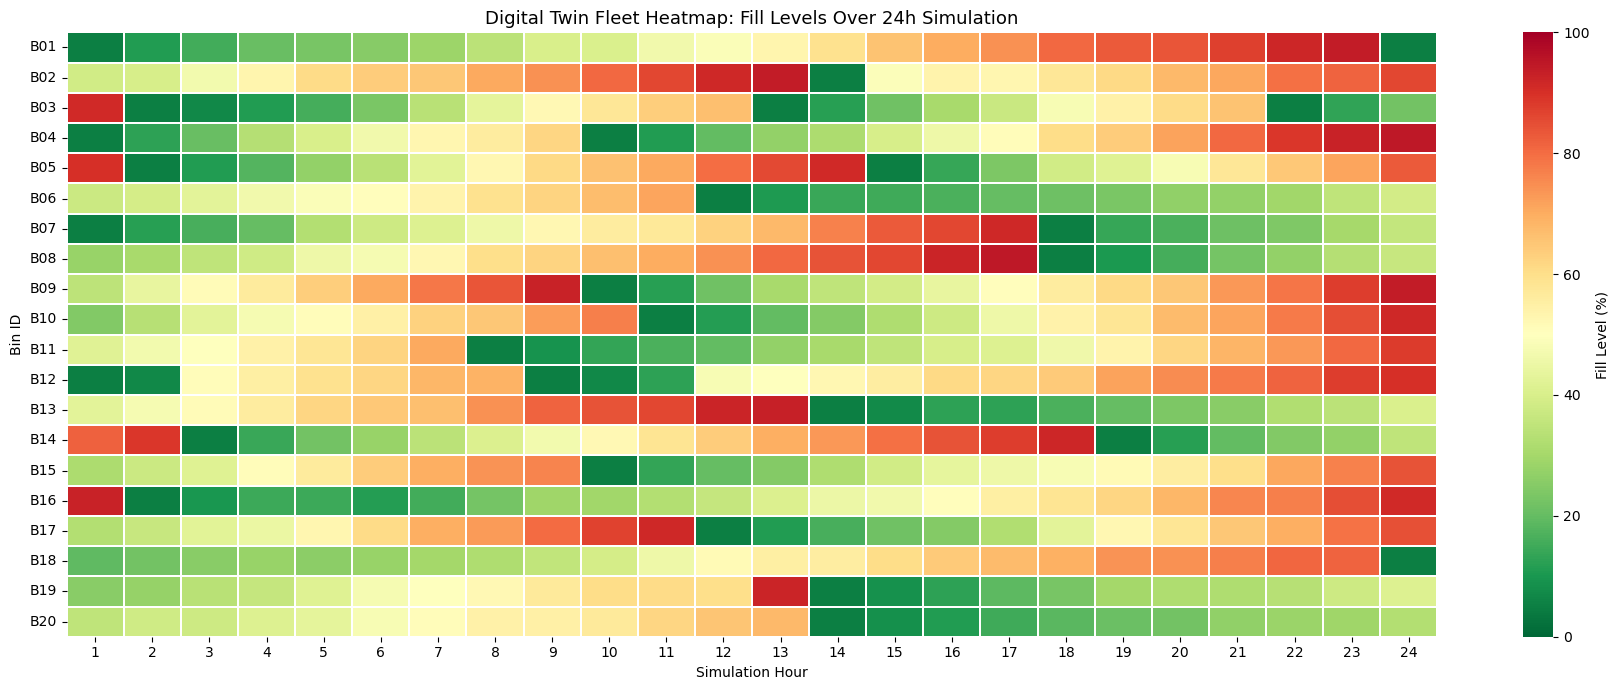

✅ Heatmap saved: digital_twin_heatmap.png


In [26]:
# ── 6.7  Heatmap: Fleet fill levels across 24-hour simulation ────────────────

heatmap_data = sim_df.pivot_table(index='Bin', columns='sim_hour', values='Fill%', aggfunc='mean')

plt.figure(figsize=(18, 7))
sns.heatmap(heatmap_data, cmap='RdYlGn_r', linewidths=0.3, annot=False, vmin=0, vmax=100,
            cbar_kws={'label': 'Fill Level (%)'})
plt.title('Digital Twin Fleet Heatmap: Fill Levels Over 24h Simulation', fontsize=13)
plt.xlabel('Simulation Hour')
plt.ylabel('Bin ID')
plt.tight_layout()
plt.savefig('digital_twin_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved: digital_twin_heatmap.png')

In [27]:
# ── 6.8  Anomaly Detection Summary ───────────────────────────────────────────

anomaly_log = []
for twin in fleet.twins.values():
    for record in twin.history:
        if record['anomaly']:
            anomaly_log.append({'Bin': twin.bin_id, 'Time': record['timestamp'],
                                'Fill': record['fill_level'], 'Alert': record['alert']})

if anomaly_log:
    anom_df = pd.DataFrame(anomaly_log)
    print(f'⚠️  Anomalies detected: {len(anom_df)}')
    print(anom_df.to_string(index=False))
else:
    print('✅ No anomalies detected in this simulation run')

print('\n📦 Bins still requiring collection after 24h:')
for twin in fleet.bins_needing_collection():
    print(f'   {twin.bin_id}: {twin.fill_level:.1f}% → predicted {twin.predicted_fill:.1f}%  [{twin.alert_level}]')

⚠️  Anomalies detected: 37
Bin                Time  Fill    Alert
B10 2026-03-12 15:00:00   5.0   normal
B18 2026-03-13 04:00:00   5.0   normal
B01 2026-03-12 05:00:00   5.0   normal
B01 2026-03-13 04:00:00   5.0   normal
B02 2026-03-12 18:00:00   5.0   normal
B02 2026-03-12 19:00:00  49.2   normal
B03 2026-03-12 06:00:00   5.0   normal
B03 2026-03-12 17:00:00 100.0 critical
B03 2026-03-12 17:00:00   5.0   normal
B03 2026-03-13 02:00:00 100.0 critical
B03 2026-03-13 02:00:00   5.0   normal
B04 2026-03-12 05:00:00   5.0   normal
B04 2026-03-12 14:00:00  96.3 critical
B04 2026-03-12 14:00:00   5.0   normal
B05 2026-03-12 06:00:00   5.0   normal
B05 2026-03-12 19:00:00   5.0   normal
B06 2026-03-12 16:00:00   5.0   normal
B07 2026-03-12 05:00:00   5.0   normal
B07 2026-03-12 22:00:00   5.0   normal
B19 2026-03-12 17:00:00  92.3 critical
B19 2026-03-12 18:00:00   5.0   normal
B08 2026-03-12 22:00:00   5.0   normal
B11 2026-03-12 12:00:00   5.0   normal
B12 2026-03-12 05:00:00   5.0   norma

In [28]:
# ── 6.9  Live Digital Twin Map (Folium) ──────────────────────────────────────

final_status = fleet.fleet_status()

twin_map = folium.Map(
    location=[seed_data['Latitude'].mean(), seed_data['Longitude'].mean()],
    zoom_start=13,
    tiles='CartoDB positron'
)

alert_colors = {'normal': 'green', 'monitor': 'blue', 'warning': 'orange', 'critical': 'red'}

for _, row in final_status.iterrows():
    twin  = fleet.twins[row['Bin']]
    color = alert_colors.get(row['Alert'], 'gray')
    radius = 8 + row['Fill%'] / 20
    folium.CircleMarker(
        location=[twin.latitude, twin.longitude],
        radius=radius, color=color, fill=True, fill_color=color, fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{row['Bin']}</b> [Digital Twin]<br>"
            f"Current Fill : {row['Fill%']:.1f}%<br>"
            f"3h Prediction: {row['Predicted3h%']}%<br>"
            f"Alert Level  : <b>{row['Alert'].upper()}</b><br>"
            f"Collect Due  : {'✅ YES' if row['CollectDue'] else '⏳ No'}",
            max_width=220
        ),
        tooltip=f"{row['Bin']}: {row['Fill%']:.0f}% [{row['Alert']}]"
    ).add_to(twin_map)

twin_legend = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
            padding:10px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
  <b>🤖 Digital Twin Alert Level</b><br>
  <span style="color:green">●</span> Normal (&lt;50%)<br>
  <span style="color:blue">●</span> Monitor (50–74%)<br>
  <span style="color:orange">●</span> Warning (75–89%)<br>
  <span style="color:red">●</span> Critical (≥90%)<br>
  <i style="font-size:11px;">Circle size ∝ fill level</i>
</div>
"""
twin_map.get_root().html.add_child(folium.Element(twin_legend))
twin_map.save('digital_twin_live_map.html')
print('✅ Digital Twin live map saved: digital_twin_live_map.html')
twin_map

✅ Digital Twin live map saved: digital_twin_live_map.html


## 📈 Section 7: Consolidated Project Summary & Metrics

In [29]:
print('=' * 60)
print('    SMART WASTE MANAGEMENT SYSTEM — PROJECT SUMMARY')
print('=' * 60)

print(f"""
📊 DATASET
   • Bins monitored         : {df['Bin_ID'].nunique()}
   • Total sensor readings  : {len(df)}
   • Date range             : {df['Timestamp'].min().date()} → {df['Timestamp'].max().date()}
   • Area types             : {', '.join(df['Area_Type'].unique())}

🤖 FILL PREDICTION (Random Forest)
   • MAE                    : {mae:.2f}%
   • R² Score               : {r2:.4f}
   • Bins flagged (latest)  : {len(bins_to_collect)} / {len(latest_bins)}

🗺️  ROUTE OPTIMIZATION (2-opt)
   • Stops in route         : {len(optimized_route) if len(bins_to_collect)>=2 else 'N/A'}
   • Distance improvement   : {((dist_before-dist_after)/dist_before)*100:.1f}% (vs nearest-neighbor)

🌐 DIGITAL TWIN (24h Simulation)
   • Twins instantiated     : {len(fleet.twins)}
   • Simulation hours       : 24
   • Total alerts raised    : {len(fleet.global_log)}
   • Anomalies detected     : {len(anomaly_log)}
   • Bins needing collection: {len(fleet.bins_needing_collection())}
""")

    SMART WASTE MANAGEMENT SYSTEM — PROJECT SUMMARY

📊 DATASET
   • Bins monitored         : 20
   • Total sensor readings  : 960
   • Date range             : 2026-03-10 → 2026-03-12
   • Area types             : Commercial, Residential

🤖 FILL PREDICTION (Random Forest)
   • MAE                    : 2.02%
   • R² Score               : 0.9886
   • Bins flagged (latest)  : 8 / 20

🗺️  ROUTE OPTIMIZATION (2-opt)
   • Stops in route         : 8
   • Distance improvement   : 11.9% (vs nearest-neighbor)

🌐 DIGITAL TWIN (24h Simulation)
   • Twins instantiated     : 20
   • Simulation hours       : 24
   • Total alerts raised    : 136
   • Anomalies detected     : 37
   • Bins needing collection: 10



## 🏙️ Section 7B: Discrete-Event Simulation (SimPy)
### Digital Twin Simulation with ML-Driven Waste Prediction

| Component | What it Simulates |
|-----------|------------------|
| `SmartBinProcess` | Dynamic waste accumulation per bin with ML-backed fill rates |
| `TruckDispatch` | Multi-truck resource pool — queuing, travel delay, emptying |
| `OverflowGuard` | Pre-emptive dispatch when predicted fill > 90% |
| `EventLogger` | Structured log → Pandas DataFrame for analysis |
| Visualisations | Timeline, heatmap, overflow frequency, truck utilisation |

> **Digital Twin philosophy:** Each bin's waste generation rate is seeded from the trained Random Forest model's feature-importance weights, making it a faithful virtual replica of real-world behaviour.

In [30]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              SIMULATION CONFIGURATION                       ║
# ╚══════════════════════════════════════════════════════════════╝

SIM_DURATION_HOURS   = 72
SENSOR_POLL_INTERVAL = 1
NUM_BINS             = 12
COLLECTION_THRESHOLD = 80
OVERFLOW_THRESHOLD   = 100
PREEMPT_THRESHOLD    = 90
NUM_TRUCKS           = 3
TRUCK_TRAVEL_MEAN    = 1.5
TRUCK_TRAVEL_STD     = 0.4
EMPTYING_TIME        = 0.25

AREA_FILL_RATES = {
    'Commercial': {'mean': 6.5, 'std': 2.0},
    'Residential': {'mean': 3.5, 'std': 1.2},
    'Industrial':  {'mean': 5.0, 'std': 1.8},
    'Park':        {'mean': 2.0, 'std': 0.8},
}

BIN_CONFIG = [
    {'id': 'BIN_C01', 'area': 'Commercial',  'init_fill': 25},
    {'id': 'BIN_C02', 'area': 'Commercial',  'init_fill': 60},
    {'id': 'BIN_C03', 'area': 'Commercial',  'init_fill': 10},
    {'id': 'BIN_R01', 'area': 'Residential', 'init_fill': 40},
    {'id': 'BIN_R02', 'area': 'Residential', 'init_fill': 55},
    {'id': 'BIN_R03', 'area': 'Residential', 'init_fill': 20},
    {'id': 'BIN_R04', 'area': 'Residential', 'init_fill': 70},
    {'id': 'BIN_I01', 'area': 'Industrial',  'init_fill': 30},
    {'id': 'BIN_I02', 'area': 'Industrial',  'init_fill': 45},
    {'id': 'BIN_P01', 'area': 'Park',        'init_fill': 15},
    {'id': 'BIN_P02', 'area': 'Park',        'init_fill': 35},
    {'id': 'BIN_P03', 'area': 'Park',        'init_fill': 50},
]

print(f'✅ SimPy Config: {NUM_BINS} bins | {NUM_TRUCKS} trucks | {SIM_DURATION_HOURS}h simulation')

✅ SimPy Config: 12 bins | 3 trucks | 72h simulation


In [31]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         ML-BACKED FILL RATE ENGINE (Digital Twin Core)      ║
# ╚══════════════════════════════════════════════════════════════╝

class MLFillRateEngine:
    def __init__(self, rf_model=None, le_area=None, le_bin=None, features=None):
        self.rf_model  = rf_model
        self.le_area   = le_area
        self.le_bin    = le_bin
        self.features  = features
        self.ml_active = rf_model is not None
        self._tod_curve = self._build_tod_curve()
        mode = 'Random Forest (ML)' if self.ml_active else 'Gaussian Fallback'
        print(f'  FillRateEngine: using {mode} mode')

    def _build_tod_curve(self):
        base  = {h: 0.5 for h in range(24)}
        peaks = {7: 1.2, 8: 1.8, 9: 2.0, 10: 1.7, 12: 1.5,
                 13: 1.4, 17: 1.9, 18: 2.2, 19: 1.8, 20: 1.3}
        base.update(peaks)
        return base

    def get_increment(self, bin_id, area_type, current_fill, sim_hour, capacity_kg=100.0):
        hour_of_day = sim_hour % 24
        day_of_week = (sim_hour // 24) % 7
        tod_mult    = self._tod_curve[hour_of_day]

        if self.ml_active:
            try:
                area_enc = self.le_area.transform([area_type])[0]
                bin_enc  = self.le_bin.transform([bin_id])[0]                            if bin_id in self.le_bin.classes_ else 0
                row = pd.DataFrame([{
                    'Fill_Level': current_fill, 'Hour': hour_of_day,
                    'Day': day_of_week, 'Capacity_kg': capacity_kg,
                    'Area_Encoded': area_enc, 'Bin_Encoded': bin_enc,
                }], columns=self.features)
                predicted_next = self.rf_model.predict(row)[0]
                increment = predicted_next - current_fill
                return float(np.clip(increment + np.random.normal(0, 0.5), 0.1, 15.0))
            except Exception:
                pass

        params    = AREA_FILL_RATES.get(area_type, {'mean': 4.0, 'std': 1.5})
        base_rate = np.random.normal(params['mean'], params['std'])
        increment = base_rate * tod_mult
        return float(np.clip(increment, 0.1, 20.0))


try:
    fill_engine = MLFillRateEngine(rf_model=rf_model, le_area=le, le_bin=le, features=features)
    print('  ✅ ML mode: using your trained Random Forest')
except NameError:
    fill_engine = MLFillRateEngine()
    print('  ℹ️  Fallback mode: rf_model not found in scope, using Gaussian model')

  FillRateEngine: using Random Forest (ML) mode
  ✅ ML mode: using your trained Random Forest


In [32]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                      EVENT LOGGER                           ║
# ╚══════════════════════════════════════════════════════════════╝

@dataclass
class SimEvent:
    sim_time:     float
    event_type:   str
    bin_id:       str
    fill_level:   float
    truck_id:     Optional[str] = None
    delay_hours:  Optional[float] = None
    message:      str = ''


class SimLogger:
    def __init__(self):
        self._events: List[SimEvent] = []

    def log(self, sim_time, event_type, bin_id, fill_level,
            truck_id=None, delay_hours=None, message=''):
        self._events.append(SimEvent(
            sim_time=round(sim_time, 3), event_type=event_type,
            bin_id=bin_id, fill_level=round(fill_level, 2),
            truck_id=truck_id,
            delay_hours=round(delay_hours, 3) if delay_hours else None,
            message=message,
        ))

    def to_dataframe(self):
        return pd.DataFrame([{
            'sim_time_h': e.sim_time, 'day': int(e.sim_time // 24) + 1,
            'hour_of_day': int(e.sim_time % 24), 'event_type': e.event_type,
            'bin_id': e.bin_id, 'fill_level': e.fill_level,
            'truck_id': e.truck_id, 'delay_hours': e.delay_hours,
            'message': e.message,
        } for e in self._events])

    def summary(self):
        df = self.to_dataframe()
        return {
            'total_events':          len(df),
            'total_collections':     len(df[df['event_type'] == 'BIN_EMPTIED']),
            'total_overflows':       len(df[df['event_type'] == 'OVERFLOW']),
            'preemptive_dispatches': len(df[df['event_type'] == 'PREEMPTIVE_DISPATCH']),
            'avg_delay_hours':       df['delay_hours'].dropna().mean(),
            'max_delay_hours':       df['delay_hours'].dropna().max(),
            'bins_with_overflow':    df[df['event_type'] == 'OVERFLOW']['bin_id'].nunique(),
        }

print('✅ SimLogger class defined')

✅ SimLogger class defined


In [33]:
# ╔══════════════════════════════════════════════════════════════╗
# ║               SMART BIN & TRUCK SIMPY PROCESSES             ║
# ╚══════════════════════════════════════════════════════════════╝

_truck_counter = defaultdict(int)

def _reset_bin(bin_id, bin_states):
    bin_states[bin_id]['just_emptied'] = True
    bin_states[bin_id]['collections']  = bin_states[bin_id].get('collections', 0) + 1


def _truck_dispatch(env, bin_id, fill_at_req, truck_pool, logger, bin_states, dispatch_type, on_empty):
    request_time = env.now
    with truck_pool.request() as req:
        yield req
        queue_delay = env.now - request_time
        truck_id    = f'TRUCK_{(truck_pool.count):02d}'
        logger.log(env.now, 'TRUCK_DISPATCHED', bin_id, fill_at_req, truck_id=truck_id,
                   delay_hours=queue_delay,
                   message=f'{truck_id} dispatched to {bin_id} (queued {queue_delay:.2f}h | type={dispatch_type})')
        travel_time = max(0.1, np.random.normal(TRUCK_TRAVEL_MEAN, TRUCK_TRAVEL_STD))
        yield env.timeout(travel_time)
        logger.log(env.now, 'TRUCK_ARRIVED', bin_id, fill_at_req, truck_id=truck_id,
                   delay_hours=travel_time,
                   message=f'{truck_id} arrived at {bin_id} after {travel_time:.2f}h travel')
        yield env.timeout(EMPTYING_TIME)
        on_empty()
        total_delay = env.now - request_time
        logger.log(env.now, 'BIN_EMPTIED', bin_id, 0.0, truck_id=truck_id,
                   delay_hours=total_delay,
                   message=f'✅ {bin_id} emptied by {truck_id} (total={total_delay:.2f}h | queue={queue_delay:.2f}h | travel={travel_time:.2f}h)')


def smart_bin_process(env, bin_cfg, truck_pool, logger, fill_engine, bin_states):
    bin_id  = bin_cfg['id']
    area    = bin_cfg['area']
    fill    = float(bin_cfg['init_fill'])
    pending = False
    bin_states[bin_id] = {'fill_history': [], 'area': area, 'collections': 0}

    while True:
        increment = fill_engine.get_increment(bin_id=bin_id, area_type=area,
                                               current_fill=fill, sim_hour=int(env.now))
        fill = min(fill + increment, OVERFLOW_THRESHOLD)
        logger.log(env.now, 'FILL_UPDATE', bin_id, fill)
        bin_states[bin_id]['fill_history'].append((round(env.now, 1), round(fill, 2)))

        if fill >= OVERFLOW_THRESHOLD:
            logger.log(env.now, 'OVERFLOW', bin_id, fill,
                       message=f'⚠️ {bin_id} OVERFLOWED at hour {env.now:.1f}!')

        if fill >= COLLECTION_THRESHOLD and not pending:
            logger.log(env.now, 'THRESHOLD_CROSSED', bin_id, fill,
                       message=f'{bin_id} fill={fill:.1f}% — requesting truck')
            pending = True
            env.process(_truck_dispatch(env, bin_id, fill, truck_pool, logger, bin_states,
                                        dispatch_type='THRESHOLD',
                                        on_empty=lambda: _reset_bin(bin_id, bin_states)))
        elif not pending:
            predicted_3h = fill + fill_engine.get_increment(bin_id, area, fill, int(env.now) + 3) * 3
            if predicted_3h >= PREEMPT_THRESHOLD:
                logger.log(env.now, 'PREEMPTIVE_DISPATCH', bin_id, fill,
                           message=f'{bin_id} predicted={predicted_3h:.1f}% — pre-emptive dispatch')
                pending = True
                env.process(_truck_dispatch(env, bin_id, fill, truck_pool, logger, bin_states,
                                            dispatch_type='PREEMPTIVE',
                                            on_empty=lambda: _reset_bin(bin_id, bin_states)))

        if bin_states[bin_id].get('just_emptied', False):
            fill = 0.0
            pending = False
            bin_states[bin_id]['just_emptied'] = False

        yield env.timeout(SENSOR_POLL_INTERVAL)

print('✅ SimPy processes defined')

✅ SimPy processes defined


In [34]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              RUN SIMULATION (MAIN ENTRY POINT)              ║
# ╚══════════════════════════════════════════════════════════════╝

def run_simulation(bin_configs=BIN_CONFIG, num_trucks=NUM_TRUCKS,
                   sim_duration=SIM_DURATION_HOURS, fill_engine_obj=None, seed=42):
    np.random.seed(seed)
    random.seed(seed)
    engine     = fill_engine_obj or fill_engine
    env        = simpy.Environment()
    truck_pool = simpy.Resource(env, capacity=num_trucks)
    logger     = SimLogger()
    bin_states = {}

    for cfg in bin_configs:
        env.process(smart_bin_process(env=env, bin_cfg=cfg, truck_pool=truck_pool,
                                       logger=logger, fill_engine=engine, bin_states=bin_states))

    print(f'🚀 Starting simulation: {len(bin_configs)} bins | {num_trucks} trucks | {sim_duration}h duration...')
    env.run(until=sim_duration)

    log_df  = logger.to_dataframe()
    summary = logger.summary()

    print(f'\n✅ Simulation complete — {len(log_df)} events logged')
    print('\n📊 KPI Summary:')
    for k, v in summary.items():
        val = f'{v:.2f}' if isinstance(v, float) else str(v)
        print(f'  {k:<28s}: {val}')

    return log_df, bin_states, summary


log_df, bin_states, kpi_summary = run_simulation()
print('\n📋 Event log preview:')
log_df[log_df['event_type'] != 'FILL_UPDATE'].head(20)

🚀 Starting simulation: 12 bins | 3 trucks | 72h duration...

✅ Simulation complete — 1036 events logged

📊 KPI Summary:
  total_events                : 1036
  total_collections           : 42
  total_overflows             : 2
  preemptive_dispatches       : 28
  avg_delay_hours             : 1.70
  max_delay_hours             : 4.05
  bins_with_overflow          : 2

📋 Event log preview:


,sim_time_h,day,hour_of_day,event_type,bin_id,fill_level,truck_id,delay_hours,message
50,4.000,1,4,PREEMPTIVE_DISPATCH,BIN_C02,73.46,None,NaN,BIN_C02 predicted=95.2% — pre-emptive dispatch
56,4.000,1,4,PREEMPTIVE_DISPATCH,BIN_R04,78.40,None,NaN,BIN_R04 predicted=90.7% — pre-emptive dispatch
59,4.000,1,4,PREEMPTIVE_DISPATCH,BIN_I02,57.56,None,NaN,BIN_I02 predicted=91.5% — pre-emptive dispatch
63,4.000,1,4,TRUCK_DISPATCHED,BIN_C02,73.46,TRUCK_03,NaN,TRUCK_03 dispatched to BIN_C02 (queued 0.00h |...
64,4.000,1,4,TRUCK_DISPATCHED,BIN_R04,78.40,TRUCK_03,NaN,TRUCK_03 dispatched to BIN_R04 (queued 0.00h |...
65,4.000,1,4,TRUCK_DISPATCHED,BIN_I02,57.56,TRUCK_03,NaN,TRUCK_03 dispatched to BIN_I02 (queued 0.00h |...
78,5.136,1,5,TRUCK_ARRIVED,BIN_R04,78.40,TRUCK_03,1.136,TRUCK_03 arrived at BIN_R04 after 1.14h travel
79,5.386,1,5,BIN_EMPTIED,BIN_R04,0.00,TRUCK_03,1.386,✅ BIN_R04 emptied by TRUCK_03 (total=1.39h | q...
80,5.816,1,5,TRUCK_ARRIVED,BIN_C02,73.46,TRUCK_03,1.816,TRUCK_03 arrived at BIN_C02 after 1.82h travel
82,6.000,1,6,PREEMPTIVE_DISPATCH,BIN_C01,47.16,None,NaN,BIN_C01 predicted=95.5% — pre-emptive dispatch


In [35]:
# ── Structured Results DataFrames ────────────────────────────────────────────

collections_df = log_df[log_df['event_type'] == 'BIN_EMPTIED'].copy()
collections_df = collections_df[['sim_time_h','day','hour_of_day','bin_id','truck_id','delay_hours','message']].reset_index(drop=True)
print(f'📦 Total collections: {len(collections_df)}')
print(collections_df.head(10).to_string(index=False))

overflow_df = log_df[log_df['event_type'] == 'OVERFLOW'][['sim_time_h','day','hour_of_day','bin_id','fill_level','message']].reset_index(drop=True)
print(f'\n⚠️  Total overflow events: {len(overflow_df)}')
if not overflow_df.empty:
    print(overflow_df.to_string(index=False))
else:
    print('  None — trucks kept up with demand! ✅')

bin_summary_rows = []
for cfg in BIN_CONFIG:
    bid   = cfg['id']
    area  = cfg['area']
    colls = bin_states[bid].get('collections', 0)
    hist  = bin_states[bid]['fill_history']
    fills = [f for _, f in hist]
    overf = len(overflow_df[overflow_df['bin_id'] == bid])
    delays = collections_df[collections_df['bin_id'] == bid]['delay_hours']
    bin_summary_rows.append({
        'bin_id': bid, 'area_type': area, 'collections': colls,
        'overflow_events': overf, 'avg_fill_%': round(np.mean(fills), 1) if fills else 0,
        'max_fill_%': round(np.max(fills), 1) if fills else 0,
        'avg_delay_h': round(delays.mean(), 2) if len(delays) > 0 else None,
    })

bin_summary_df = pd.DataFrame(bin_summary_rows)
print('\n📊 Per-Bin Summary:')
print(bin_summary_df.to_string(index=False))

📦 Total collections: 42
 sim_time_h  day  hour_of_day  bin_id truck_id  delay_hours                                                                  message
      5.386    1            5 BIN_R04 TRUCK_03        1.386 ✅ BIN_R04 emptied by TRUCK_03 (total=1.39h | queue=0.00h | travel=1.14h)
      6.066    1            6 BIN_C02 TRUCK_03        2.066 ✅ BIN_C02 emptied by TRUCK_03 (total=2.07h | queue=0.00h | travel=1.82h)
      6.311    1            6 BIN_I02 TRUCK_03        2.311 ✅ BIN_I02 emptied by TRUCK_03 (total=2.31h | queue=0.00h | travel=2.06h)
      7.915    1            7 BIN_C01 TRUCK_03        1.915 ✅ BIN_C01 emptied by TRUCK_03 (total=1.92h | queue=0.00h | travel=1.67h)
      8.721    1            8 BIN_I01 TRUCK_02        1.721 ✅ BIN_I01 emptied by TRUCK_02 (total=1.72h | queue=0.00h | travel=1.47h)
     10.489    1           10 BIN_R02 TRUCK_02        1.489 ✅ BIN_R02 emptied by TRUCK_02 (total=1.49h | queue=0.00h | travel=1.24h)
     10.768    1           10 BIN_C03 TRUCK_0

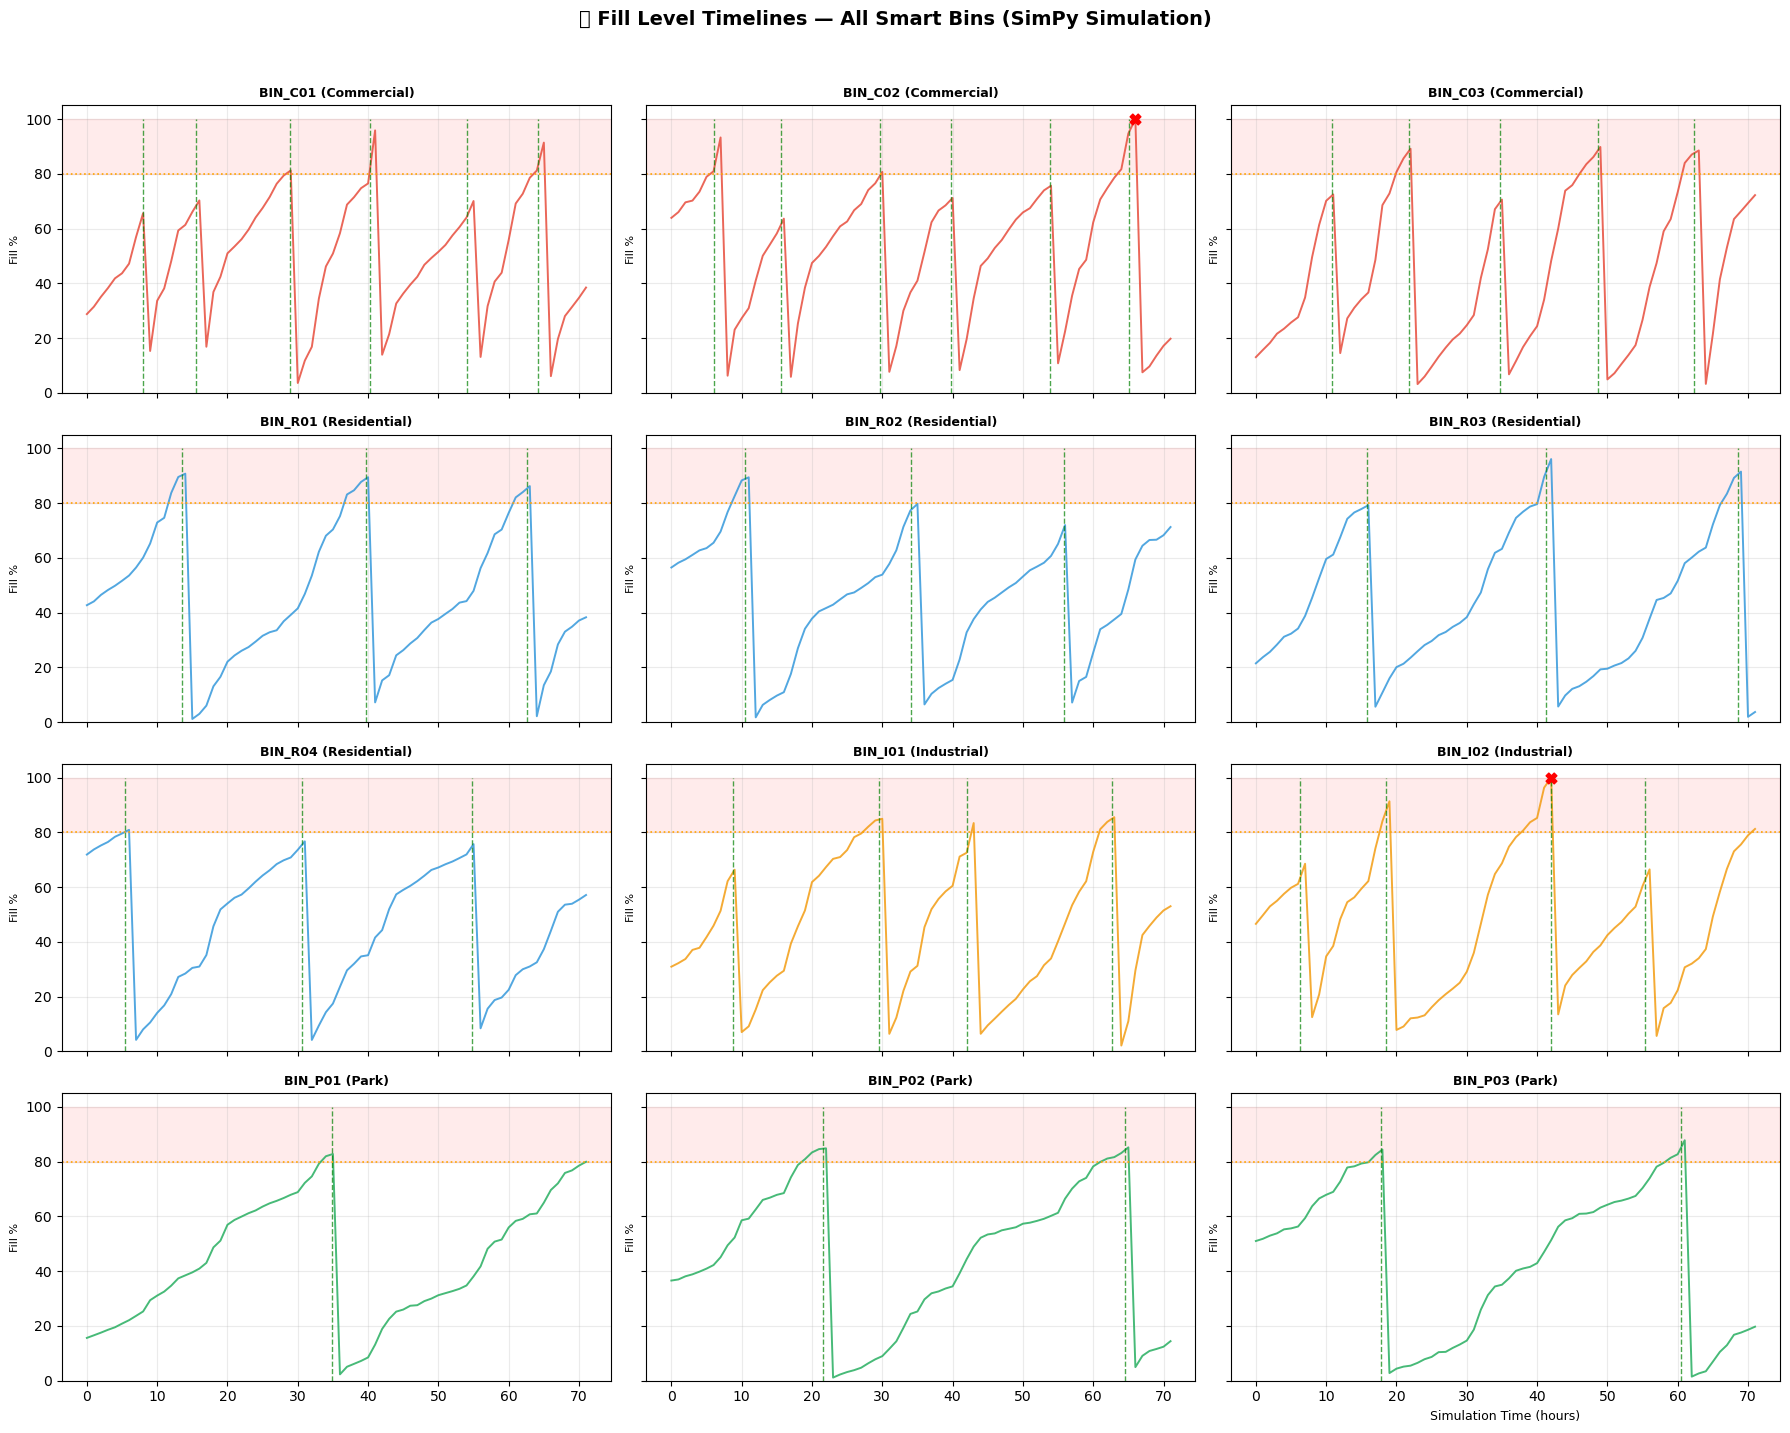

✅ Saved: sim_fill_timelines.png


In [36]:
# ── Chart 1: Fill Level Timelines ────────────────────────────────────────────

fill_df = log_df[log_df['event_type'] == 'FILL_UPDATE'].copy()
bins    = [cfg['id'] for cfg in BIN_CONFIG]
ncols   = 3
nrows   = (len(bins) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5), sharex=True, sharey=True)
axes = axes.flatten()

AREA_COLORS = {'Commercial': '#E74C3C', 'Residential': '#3498DB',
               'Industrial': '#F39C12', 'Park': '#27AE60'}

for i, bid in enumerate(bins):
    ax   = axes[i]
    area = bin_states[bid]['area']
    bdf  = fill_df[fill_df['bin_id'] == bid]
    ax.plot(bdf['sim_time_h'], bdf['fill_level'], color=AREA_COLORS.get(area, 'gray'),
            linewidth=1.4, alpha=0.85)
    ax.axhspan(COLLECTION_THRESHOLD, 100, alpha=0.08, color='red')
    emp = log_df[(log_df['event_type'] == 'BIN_EMPTIED') & (log_df['bin_id'] == bid)]
    ax.vlines(emp['sim_time_h'], 0, 100, color='green', linestyle='--', linewidth=1.0, alpha=0.7)
    ovf = log_df[(log_df['event_type'] == 'OVERFLOW') & (log_df['bin_id'] == bid)]
    if not ovf.empty:
        ax.scatter(ovf['sim_time_h'], ovf['fill_level'], color='red', zorder=5, s=60, marker='X')
    ax.axhline(COLLECTION_THRESHOLD, color='orange', linestyle=':', linewidth=1.2)
    ax.set_title(f'{bid} ({area})', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_ylabel('Fill %', fontsize=8)
    ax.grid(True, alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('📈 Fill Level Timelines — All Smart Bins (SimPy Simulation)', fontsize=14, fontweight='bold', y=1.02)
plt.xlabel('Simulation Time (hours)', fontsize=9)
plt.tight_layout()
plt.savefig('sim_fill_timelines.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sim_fill_timelines.png')

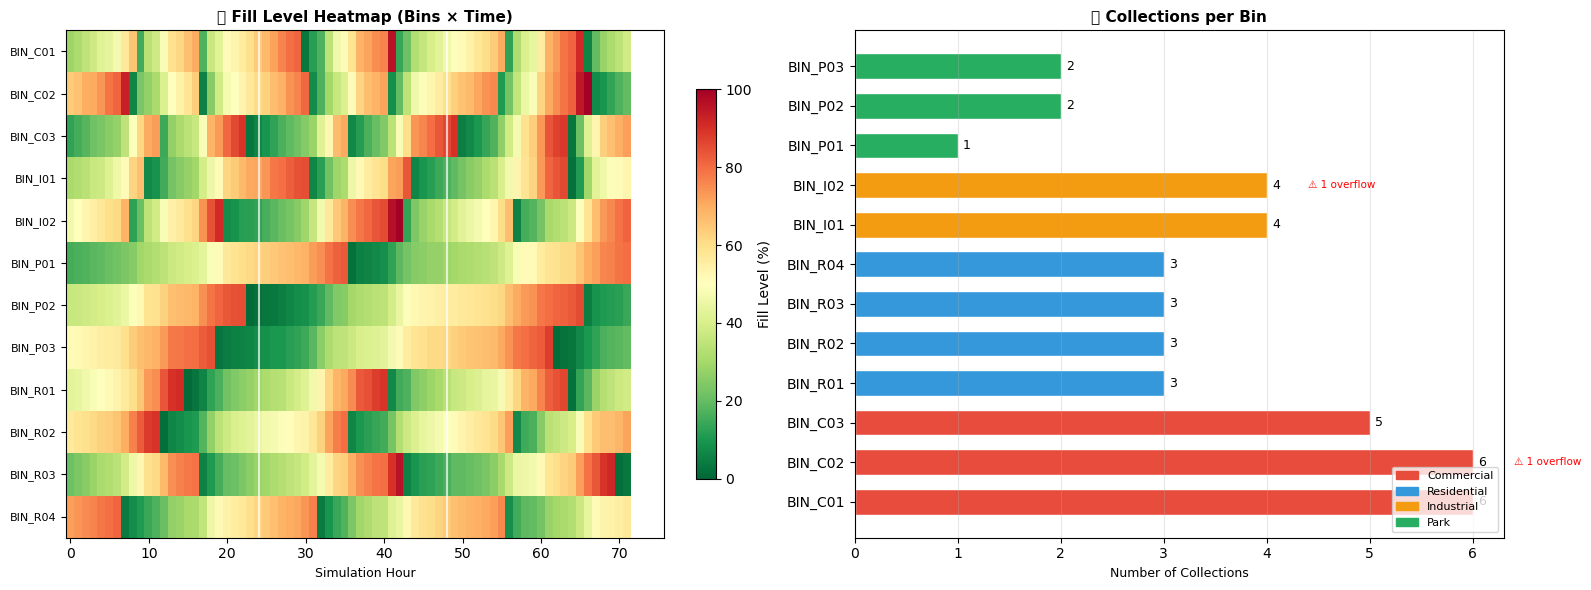

✅ Saved: sim_heatmap_collections.png


In [37]:
# ── Chart 2: Heatmap + Collections per Bin ───────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

pivot_df = fill_df.copy()
pivot_df['sim_hour_int'] = pivot_df['sim_time_h'].astype(int)
heatmap_data = pivot_df.groupby(['bin_id', 'sim_hour_int'])['fill_level'].last().unstack(fill_value=0)
order = sorted(bins, key=lambda b: bin_states[b]['area'])
heatmap_data = heatmap_data.reindex(order)

im = ax1.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100, interpolation='nearest')
ax1.set_yticks(range(len(order)))
ax1.set_yticklabels(order, fontsize=8)
ax1.set_xlabel('Simulation Hour', fontsize=9)
ax1.set_title('🌡️ Fill Level Heatmap (Bins × Time)', fontsize=11, fontweight='bold')
for day in range(1, SIM_DURATION_HOURS // 24 + 1):
    ax1.axvline(day * 24, color='white', linewidth=1.5, linestyle='-', alpha=0.7)
plt.colorbar(im, ax=ax1, label='Fill Level (%)', fraction=0.03)

colors = [AREA_COLORS.get(bin_states[b]['area'], 'gray') for b in bin_summary_df['bin_id']]
bars   = ax2.barh(bin_summary_df['bin_id'], bin_summary_df['collections'], color=colors, edgecolor='white', height=0.65)
for bar, val in zip(bars, bin_summary_df['collections']):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, str(int(val)), va='center', fontsize=9)

ax2.set_xlabel('Number of Collections', fontsize=9)
ax2.set_title('🚛 Collections per Bin', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for idx, row in bin_summary_df.iterrows():
    if row['overflow_events'] > 0:
        ax2.text(row['collections'] + 0.4, idx, f"⚠️ {int(row['overflow_events'])} overflow", va='center', fontsize=7.5, color='red')

legend_patches = [mpatches.Patch(color=c, label=a) for a, c in AREA_COLORS.items()]
ax2.legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('sim_heatmap_collections.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sim_heatmap_collections.png')

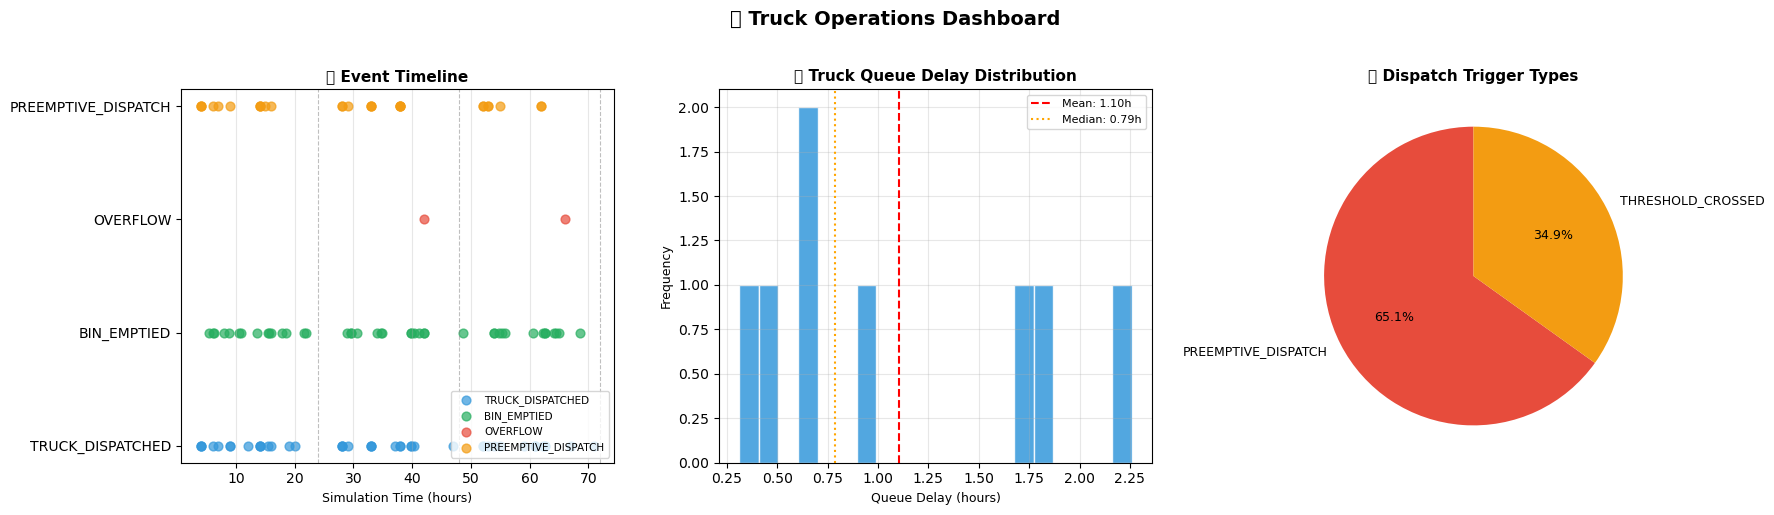

✅ Saved: sim_truck_dashboard.png


In [38]:
# ── Chart 3: Truck Utilisation & Delay Distribution ─────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dispatch_events = ['TRUCK_DISPATCHED', 'BIN_EMPTIED', 'OVERFLOW', 'PREEMPTIVE_DISPATCH']
event_colors    = {'TRUCK_DISPATCHED': '#3498DB', 'BIN_EMPTIED': '#27AE60',
                   'OVERFLOW': '#E74C3C', 'PREEMPTIVE_DISPATCH': '#F39C12'}

for etype in dispatch_events:
    sub = log_df[log_df['event_type'] == etype]
    if not sub.empty:
        axes[0].scatter(sub['sim_time_h'], [etype] * len(sub),
                        c=event_colors[etype], s=40, alpha=0.7, label=etype)

for day in range(1, SIM_DURATION_HOURS // 24 + 1):
    axes[0].axvline(day * 24, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[0].set_xlabel('Simulation Time (hours)', fontsize=9)
axes[0].set_title('🗓️ Event Timeline', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=7.5, loc='lower right')
axes[0].grid(alpha=0.3, axis='x')

dispatched = log_df[log_df['event_type'] == 'TRUCK_DISPATCHED']
if not dispatched.empty:
    delays = dispatched['delay_hours'].dropna()
    axes[1].hist(delays, bins=20, color='#3498DB', edgecolor='white', alpha=0.85)
    axes[1].axvline(delays.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {delays.mean():.2f}h')
    axes[1].axvline(delays.median(), color='orange', linestyle=':', linewidth=1.5, label=f'Median: {delays.median():.2f}h')
    axes[1].set_xlabel('Queue Delay (hours)', fontsize=9)
    axes[1].set_ylabel('Frequency', fontsize=9)
    axes[1].set_title('⏱️ Truck Queue Delay Distribution', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

type_counts = log_df[log_df['event_type'].isin(['THRESHOLD_CROSSED', 'PREEMPTIVE_DISPATCH'])]['event_type'].value_counts()
if not type_counts.empty:
    axes[2].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
                colors=['#E74C3C', '#F39C12'], startangle=90, textprops={'fontsize': 9})
    axes[2].set_title('🚦 Dispatch Trigger Types', fontsize=11, fontweight='bold')

plt.suptitle('🚛 Truck Operations Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sim_truck_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sim_truck_dashboard.png')

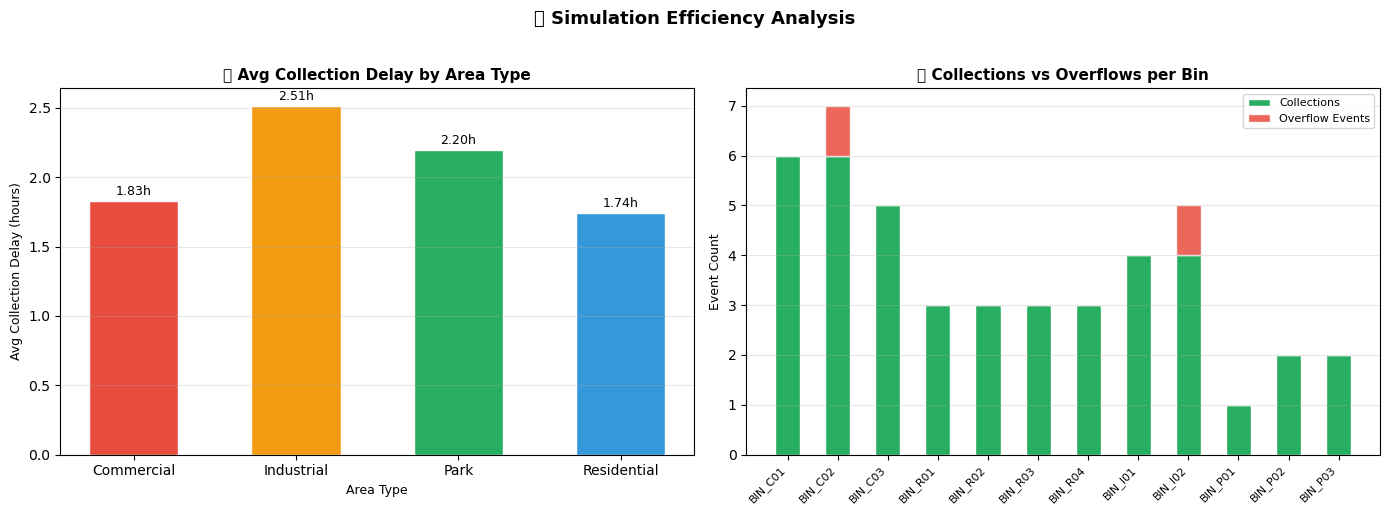

✅ Saved: sim_efficiency.png


In [39]:
# ── Chart 4: Area Efficiency + Overflow Frequency ────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bin_summary_df['area_type'] = bin_summary_df['bin_id'].map({cfg['id']: cfg['area'] for cfg in BIN_CONFIG})
area_delay  = bin_summary_df.groupby('area_type')['avg_delay_h'].mean().dropna()
colors_area = [AREA_COLORS.get(a, 'gray') for a in area_delay.index]

bars = ax1.bar(area_delay.index, area_delay.values, color=colors_area, edgecolor='white', width=0.55)
for bar, val in zip(bars, area_delay.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{val:.2f}h', ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Area Type', fontsize=9)
ax1.set_ylabel('Avg Collection Delay (hours)', fontsize=9)
ax1.set_title('⏱️ Avg Collection Delay by Area Type', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

x = np.arange(len(bin_summary_df))
ax2.bar(x, bin_summary_df['collections'], 0.5, label='Collections', color='#27AE60', edgecolor='white')
ax2.bar(x, bin_summary_df['overflow_events'], 0.5, bottom=bin_summary_df['collections'],
        label='Overflow Events', color='#E74C3C', edgecolor='white', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(bin_summary_df['bin_id'], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Event Count', fontsize=9)
ax2.set_title('📊 Collections vs Overflows per Bin', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('🏙️ Simulation Efficiency Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sim_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sim_efficiency.png')

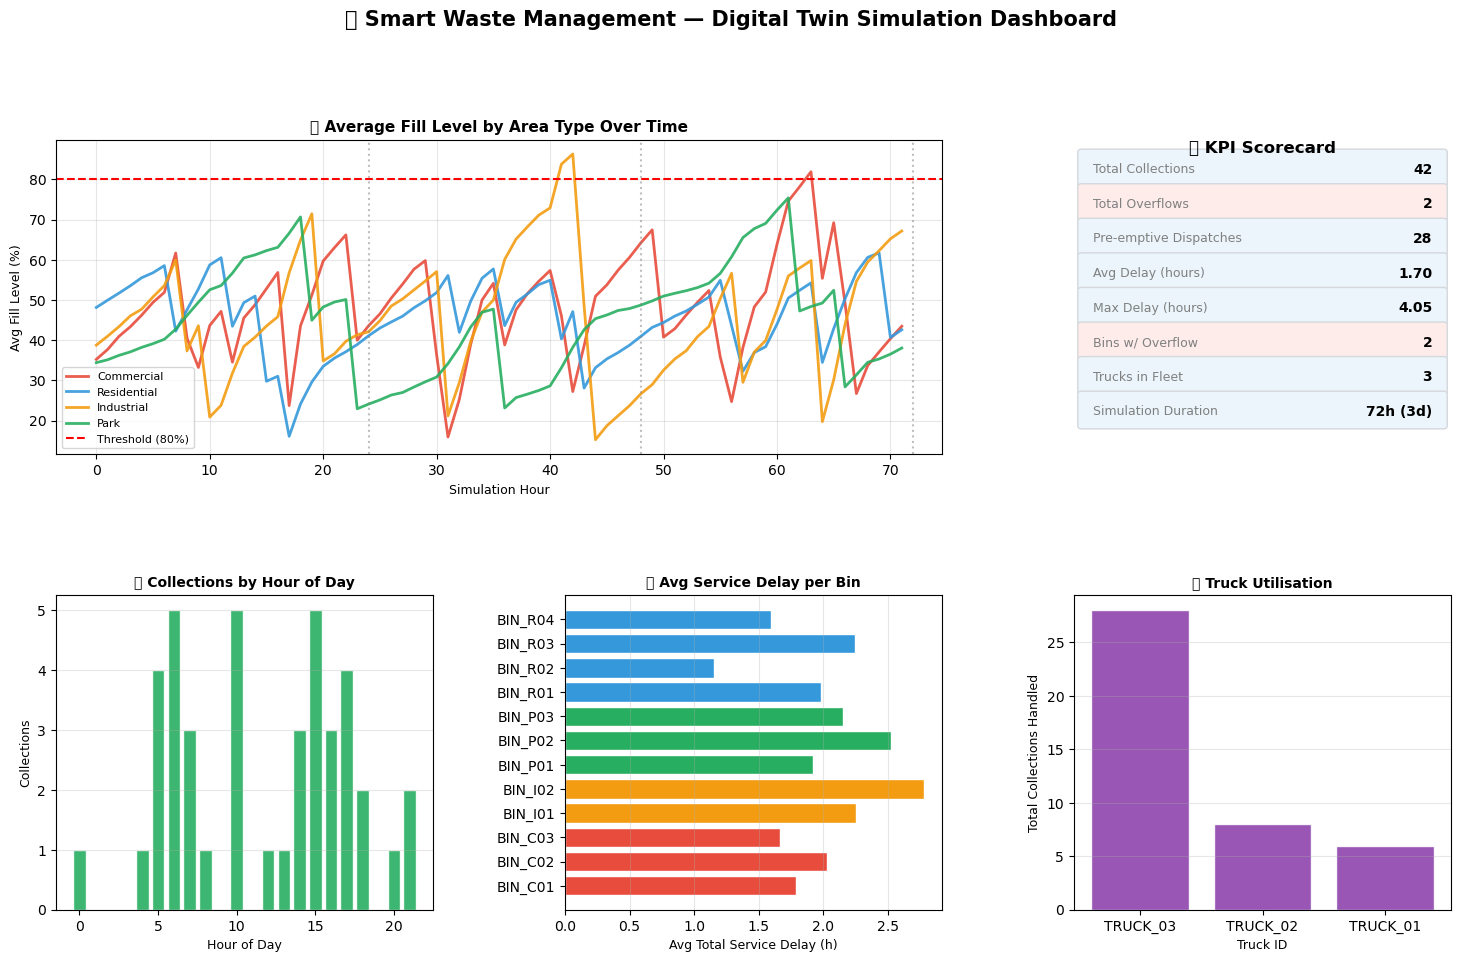

✅ Saved: sim_digital_twin_dashboard.png


In [40]:
# ── Chart 5: Digital Twin Dashboard ─────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax_top = fig.add_subplot(gs[0, :2])
for area in AREA_FILL_RATES:
    area_bins = [b['id'] for b in BIN_CONFIG if b['area'] == area]
    area_fill = fill_df[fill_df['bin_id'].isin(area_bins)]
    grouped   = area_fill.groupby('sim_time_h')['fill_level'].mean()
    ax_top.plot(grouped.index, grouped.values, color=AREA_COLORS[area], linewidth=2, label=area, alpha=0.9)

ax_top.axhline(COLLECTION_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({COLLECTION_THRESHOLD}%)')
ax_top.set_xlabel('Simulation Hour', fontsize=9)
ax_top.set_ylabel('Avg Fill Level (%)', fontsize=9)
ax_top.set_title('📈 Average Fill Level by Area Type Over Time', fontsize=11, fontweight='bold')
ax_top.legend(fontsize=8)
ax_top.grid(alpha=0.3)
for day in range(1, SIM_DURATION_HOURS // 24 + 1):
    ax_top.axvline(day * 24, color='gray', linestyle=':', alpha=0.5)

ax_kpi = fig.add_subplot(gs[0, 2])
ax_kpi.axis('off')
kpi_labels = [
    ('Total Collections',      kpi_summary['total_collections']),
    ('Total Overflows',        kpi_summary['total_overflows']),
    ('Pre-emptive Dispatches', kpi_summary['preemptive_dispatches']),
    ('Avg Delay (hours)',      f"{kpi_summary['avg_delay_hours']:.2f}" if kpi_summary['avg_delay_hours'] else 'N/A'),
    ('Max Delay (hours)',      f"{kpi_summary['max_delay_hours']:.2f}" if kpi_summary['max_delay_hours'] else 'N/A'),
    ('Bins w/ Overflow',       kpi_summary['bins_with_overflow']),
    ('Trucks in Fleet',        NUM_TRUCKS),
    ('Simulation Duration',    f'{SIM_DURATION_HOURS}h ({SIM_DURATION_HOURS//24}d)'),
]
ax_kpi.text(0.5, 1.0, '📋 KPI Scorecard', ha='center', va='top', fontsize=12, fontweight='bold', transform=ax_kpi.transAxes)
for i, (label, val) in enumerate(kpi_labels):
    y_pos  = 0.88 - i * 0.11
    bg_col = '#FDECEA' if ('Overflow' in label and int(str(val).replace('N/A','0')) > 0) else '#EBF5FB'
    ax_kpi.text(0.05, y_pos + 0.025, label, ha='left', va='center', fontsize=9, color='gray', transform=ax_kpi.transAxes)
    ax_kpi.text(0.95, y_pos + 0.025, str(val), ha='right', va='center', fontsize=10, fontweight='bold', transform=ax_kpi.transAxes)
    rect = mpatches.FancyBboxPatch((0.02, y_pos - 0.02), 0.96, 0.10, boxstyle='round,pad=0.01',
                                    facecolor=bg_col, edgecolor='#D5D8DC', transform=ax_kpi.transAxes, clip_on=False)
    ax_kpi.add_patch(rect)

ax_hourly = fig.add_subplot(gs[1, 0])
hourly_col = collections_df.groupby('hour_of_day').size()
ax_hourly.bar(hourly_col.index, hourly_col.values, color='#27AE60', edgecolor='white', alpha=0.9)
ax_hourly.set_xlabel('Hour of Day', fontsize=9)
ax_hourly.set_ylabel('Collections', fontsize=9)
ax_hourly.set_title('🕐 Collections by Hour of Day', fontsize=10, fontweight='bold')
ax_hourly.grid(axis='y', alpha=0.3)

ax_delay = fig.add_subplot(gs[1, 1])
total_delay = log_df[log_df['event_type'] == 'BIN_EMPTIED'].groupby('bin_id')['delay_hours'].mean()
bar_colors  = [AREA_COLORS.get(bin_states[b]['area'], 'gray') for b in total_delay.index]
ax_delay.barh(total_delay.index, total_delay.values, color=bar_colors, edgecolor='white')
ax_delay.set_xlabel('Avg Total Service Delay (h)', fontsize=9)
ax_delay.set_title('⏱️ Avg Service Delay per Bin', fontsize=10, fontweight='bold')
ax_delay.grid(axis='x', alpha=0.3)

ax_util = fig.add_subplot(gs[1, 2])
truck_util_vals = log_df[log_df['event_type'] == 'BIN_EMPTIED']['truck_id'].value_counts()
if not truck_util_vals.empty:
    ax_util.bar(truck_util_vals.index, truck_util_vals.values, color='#8E44AD', edgecolor='white', alpha=0.9)
    ax_util.set_xlabel('Truck ID', fontsize=9)
    ax_util.set_ylabel('Total Collections Handled', fontsize=9)
    ax_util.set_title('🚛 Truck Utilisation', fontsize=10, fontweight='bold')
    ax_util.grid(axis='y', alpha=0.3)

fig.suptitle('🏙️ Smart Waste Management — Digital Twin Simulation Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('sim_digital_twin_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sim_digital_twin_dashboard.png')

In [41]:
# ── Sensitivity Analysis: Fleet Size ─────────────────────────────────────────

fleet_results = []
for n_trucks in range(1, 6):
    log_, states_, summ_ = run_simulation(num_trucks=n_trucks, seed=42)
    fleet_results.append({
        'num_trucks':          n_trucks,
        'total_collections':   summ_['total_collections'],
        'total_overflows':     summ_['total_overflows'],
        'avg_delay_hours':     summ_['avg_delay_hours'] or 0,
        'preemptive_dispatch': summ_['preemptive_dispatches'],
    })

fleet_df = pd.DataFrame(fleet_results)
print(fleet_df.to_string(index=False))

🚀 Starting simulation: 12 bins | 1 trucks | 72h duration...

✅ Simulation complete — 1053 events logged

📊 KPI Summary:
  total_events                : 1053
  total_collections           : 36
  total_overflows             : 41
  preemptive_dispatches       : 21
  avg_delay_hours             : 3.49
  max_delay_hours             : 11.04
  bins_with_overflow          : 9
🚀 Starting simulation: 12 bins | 2 trucks | 72h duration...

✅ Simulation complete — 1041 events logged

📊 KPI Summary:
  total_events                : 1041
  total_collections           : 43
  total_overflows             : 5
  preemptive_dispatches       : 29
  avg_delay_hours             : 1.59
  max_delay_hours             : 4.52
  bins_with_overflow          : 3
🚀 Starting simulation: 12 bins | 3 trucks | 72h duration...

✅ Simulation complete — 1036 events logged

📊 KPI Summary:
  total_events                : 1036
  total_collections           : 42
  total_overflows             : 2
  preemptive_dispatches       : 28

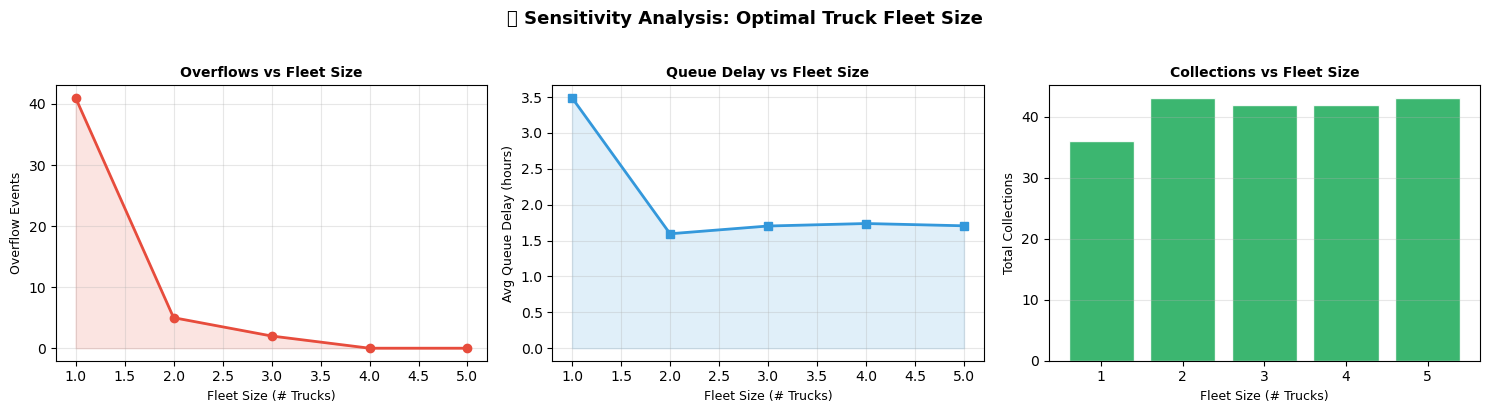


🎯 Recommended fleet size: 4 trucks
   Overflows  : 0
   Avg delay  : 1.74h
   Collections: 42


In [42]:
# ── Fleet sensitivity visualisation ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(fleet_df['num_trucks'], fleet_df['total_overflows'], marker='o', color='#E74C3C', linewidth=2)
axes[0].fill_between(fleet_df['num_trucks'], fleet_df['total_overflows'], alpha=0.15, color='#E74C3C')
axes[0].set_xlabel('Fleet Size (# Trucks)', fontsize=9); axes[0].set_ylabel('Overflow Events', fontsize=9)
axes[0].set_title('Overflows vs Fleet Size', fontsize=10, fontweight='bold'); axes[0].grid(alpha=0.3)

axes[1].plot(fleet_df['num_trucks'], fleet_df['avg_delay_hours'], marker='s', color='#3498DB', linewidth=2)
axes[1].fill_between(fleet_df['num_trucks'], fleet_df['avg_delay_hours'], alpha=0.15, color='#3498DB')
axes[1].set_xlabel('Fleet Size (# Trucks)', fontsize=9); axes[1].set_ylabel('Avg Queue Delay (hours)', fontsize=9)
axes[1].set_title('Queue Delay vs Fleet Size', fontsize=10, fontweight='bold'); axes[1].grid(alpha=0.3)

axes[2].bar(fleet_df['num_trucks'], fleet_df['total_collections'], color='#27AE60', edgecolor='white', alpha=0.9)
axes[2].set_xlabel('Fleet Size (# Trucks)', fontsize=9); axes[2].set_ylabel('Total Collections', fontsize=9)
axes[2].set_title('Collections vs Fleet Size', fontsize=10, fontweight='bold'); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('🔬 Sensitivity Analysis: Optimal Truck Fleet Size', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sim_fleet_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

opt_row = fleet_df[fleet_df['total_overflows'] == 0].iloc[0] if any(fleet_df['total_overflows'] == 0) else fleet_df.iloc[-1]
print(f'\n🎯 Recommended fleet size: {int(opt_row["num_trucks"])} trucks')
print(f'   Overflows  : {int(opt_row["total_overflows"])}')
print(f'   Avg delay  : {opt_row["avg_delay_hours"]:.2f}h')
print(f'   Collections: {int(opt_row["total_collections"])}')

In [43]:
# ── Export Results ────────────────────────────────────────────────────────────

log_df.to_csv('sim_event_log.csv', index=False)
collections_df.to_csv('sim_collections.csv', index=False)
bin_summary_df.to_csv('sim_bin_summary.csv', index=False)
fleet_df.to_csv('sim_fleet_sensitivity.csv', index=False)

print('=' * 65)
print('   DIGITAL TWIN SIMULATION — FINAL SUMMARY')
print('=' * 65)
print(f'  Simulation duration   : {SIM_DURATION_HOURS}h ({SIM_DURATION_HOURS//24} days)')
print(f'  Smart bins monitored  : {NUM_BINS}')
print(f'  Truck fleet size      : {NUM_TRUCKS}')
print(f'  Collection threshold  : {COLLECTION_THRESHOLD}%')
print(f'  Preemption threshold  : {PREEMPT_THRESHOLD}% (predicted fill)')
print(f'  Total collections     : {kpi_summary["total_collections"]}')
print(f'  Overflow events       : {kpi_summary["total_overflows"]}')
print(f'  Pre-emptive dispatches: {kpi_summary["preemptive_dispatches"]}')
print('  ✅ All CSVs exported')

   DIGITAL TWIN SIMULATION — FINAL SUMMARY
  Simulation duration   : 72h (3 days)
  Smart bins monitored  : 12
  Truck fleet size      : 3
  Collection threshold  : 80%
  Preemption threshold  : 90% (predicted fill)
  Total collections     : 42
  Overflow events       : 2
  Pre-emptive dispatches: 28
  ✅ All CSVs exported


## 🔍 Section 8: Explainable AI (XAI) — SHAP & LIME

### 🌳 SHAP Analysis — Random Forest Regressor (Fill Level Prediction)
SHAP computes each feature's **marginal contribution** using Shapley values from cooperative game theory.

### 🍋 LIME Analysis — Local Explanations for Individual Predictions
LIME fits a simple linear model **locally** around each prediction.

In [44]:
import shap
import lime
import lime.lime_tabular
print('✅ XAI libraries loaded')

✅ XAI libraries loaded


In [45]:
# ── 8.2  SHAP — Random Forest Regressor ─────────────────────────────────────
explainer_rf = shap.TreeExplainer(rf_model)
X_test_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

print(f'SHAP values shape : {shap_values_rf.shape}')
print(f'Features          : {features}')
print('✅ SHAP values computed for RF Regressor')

SHAP values shape : (188, 6)
Features          : ['Fill_Level', 'Hour', 'Day', 'Capacity_kg', 'Area_Encoded', 'Bin_Encoded']
✅ SHAP values computed for RF Regressor


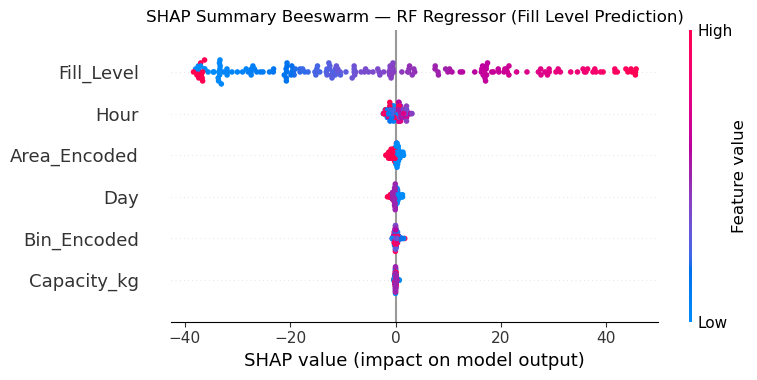

✅ Saved: shap_rf_summary.png


In [46]:
# ── 8.3  SHAP Summary Plot (Beeswarm) ────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_test_sample, feature_names=features, plot_type='dot', show=False)
plt.title('SHAP Summary Beeswarm — RF Regressor (Fill Level Prediction)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_rf_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: shap_rf_summary.png')

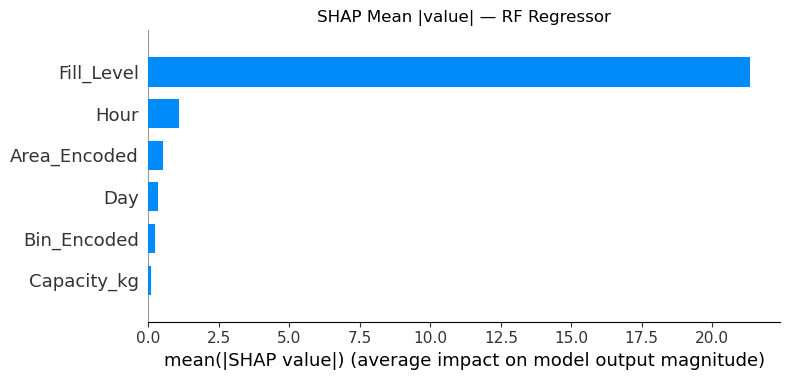

✅ Saved: shap_rf_bar.png


In [47]:
# ── 8.4  SHAP Bar Plot — Global Feature Importance ──────────────────────────
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_rf, X_test_sample, feature_names=features, plot_type='bar', show=False)
plt.title('SHAP Mean |value| — RF Regressor', fontsize=12)
plt.tight_layout()
plt.savefig('shap_rf_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: shap_rf_bar.png')

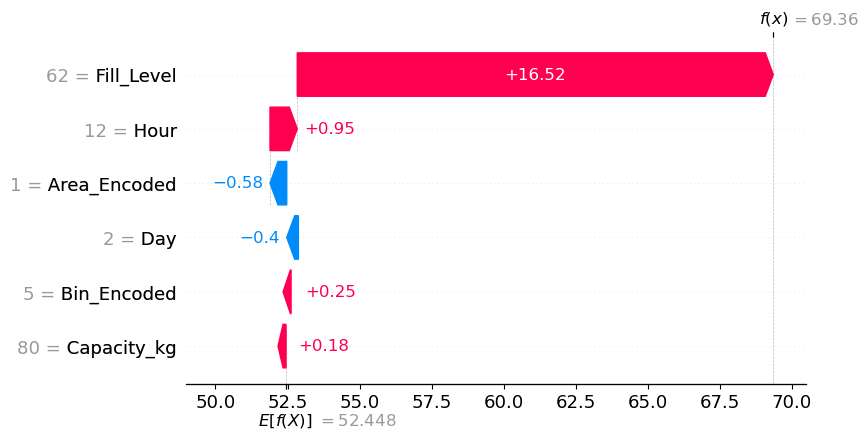

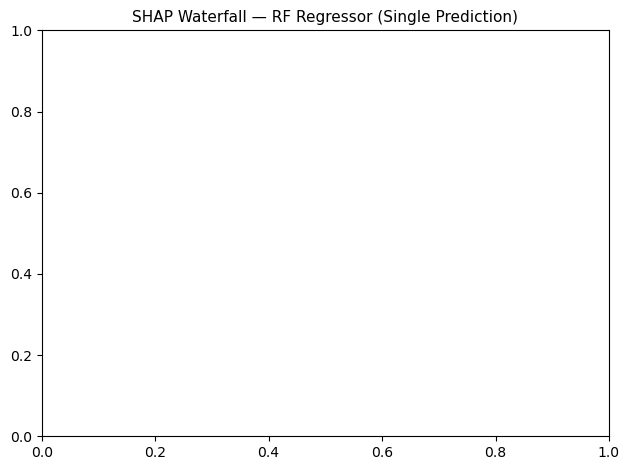

✅ Saved: shap_rf_waterfall.png


In [48]:
# ── 8.5  SHAP Waterfall — Single Prediction ─────────────────────────────────
idx = 0
expected_value_rf = explainer_rf.expected_value

shap.waterfall_plot(shap.Explanation(
    values=shap_values_rf[idx], base_values=expected_value_rf,
    data=X_test_sample.iloc[idx].values, feature_names=features
))
plt.title('SHAP Waterfall — RF Regressor (Single Prediction)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_rf_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: shap_rf_waterfall.png')

In [49]:
# ── 8.6  SHAP — Gradient Boosting Classifier ────────────────────────────────
explainer_clf = shap.TreeExplainer(clf)
X_te_sample = X_te.sample(n=min(200, len(X_te)), random_state=42)
shap_values_clf = explainer_clf.shap_values(X_te_sample)

print(f'SHAP values shape : {np.array(shap_values_clf).shape}')
print(f'Features          : {features_sb}')
print('✅ SHAP values computed for GBM Classifier')

SHAP values shape : (200, 9)
Features          : ['FL_B', 'FL_A', 'VS', 'FL_B_3', 'FL_A_3', 'FL_B_12', 'FL_A_12', 'Container Type', 'Recyclable fraction']
✅ SHAP values computed for GBM Classifier


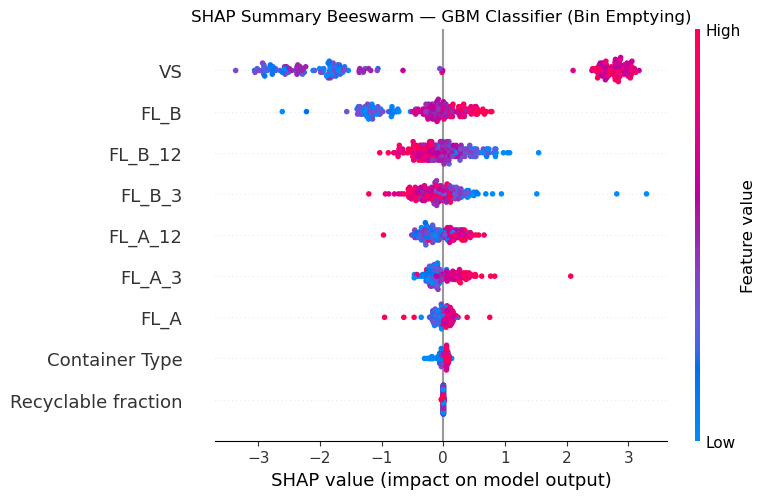

✅ Saved: shap_clf_summary.png


In [50]:
# ── 8.7  SHAP Summary Plot — GBM Classifier ─────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_clf, X_te_sample, feature_names=features_sb, plot_type='dot', show=False)
plt.title('SHAP Summary Beeswarm — GBM Classifier (Bin Emptying)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_clf_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: shap_clf_summary.png')

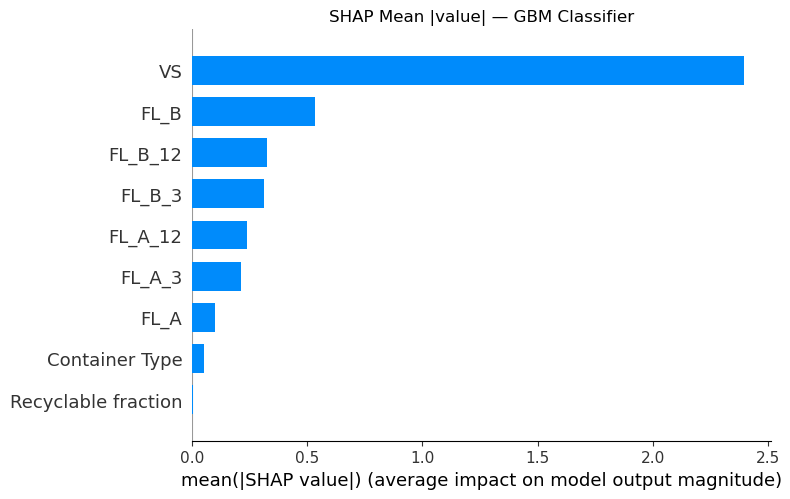

✅ Saved: shap_clf_bar.png


In [51]:
# ── 8.8  SHAP Bar Plot — GBM Classifier ─────────────────────────────────────
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_clf, X_te_sample, feature_names=features_sb, plot_type='bar', show=False)
plt.title('SHAP Mean |value| — GBM Classifier', fontsize=12)
plt.tight_layout()
plt.savefig('shap_clf_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: shap_clf_bar.png')

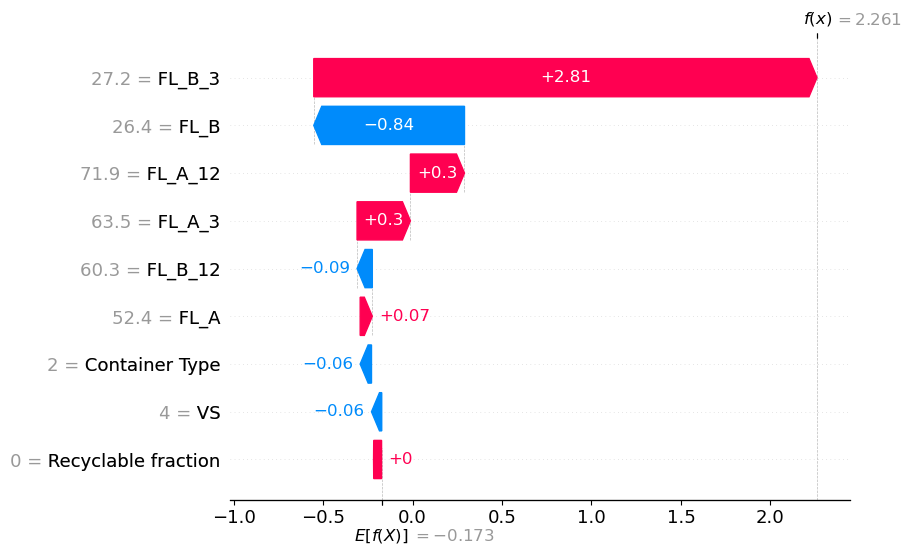

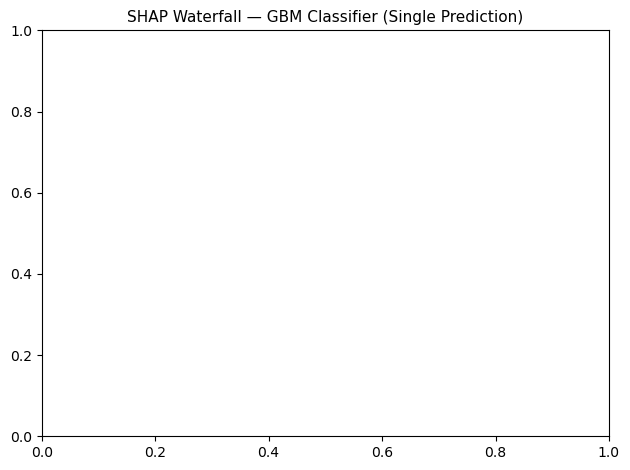

✅ Saved: shap_clf_waterfall.png


In [52]:
# ── 8.9  SHAP Waterfall — GBM Classifier ────────────────────────────────────
idx_clf = 0
exp_val_clf = explainer_clf.expected_value

shap.waterfall_plot(shap.Explanation(
    values=shap_values_clf[idx_clf], base_values=exp_val_clf,
    data=X_te_sample.iloc[idx_clf].values, feature_names=features_sb
))
plt.title('SHAP Waterfall — GBM Classifier (Single Prediction)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_clf_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: shap_clf_waterfall.png')

LIME Explanation — RF Regressor (Instance 0)
--------------------------------------------------
  49.00 < Fill_Level <= 73.00         -> raises fill prediction  (+17.3561)
  0.00 < Area_Encoded <= 1.00         -> lowers fill prediction  (-1.1549)
  6.00 < Hour <= 12.00                -> raises fill prediction  (+0.7126)
  Capacity_kg <= 100.00               -> lowers fill prediction  (-0.6164)
  1.00 < Day <= 2.00                  -> lowers fill prediction  (-0.1674)
  4.00 < Bin_Encoded <= 10.00         -> lowers fill prediction  (-0.0022)


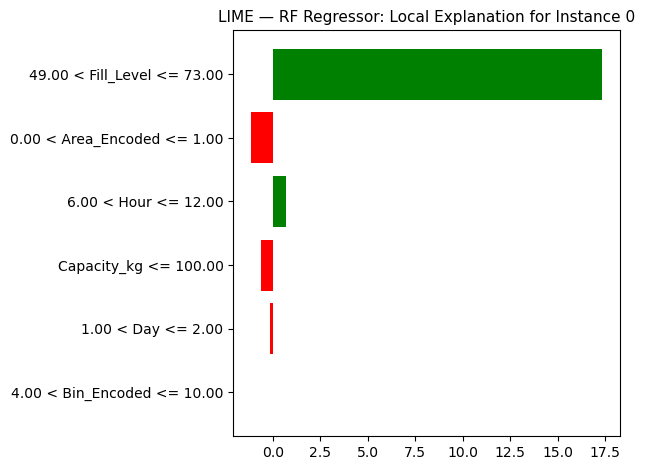


✅ Saved: lime_rf_instance.png


In [53]:
# ── 8.10  LIME — Random Forest Regressor ────────────────────────────────────
lime_explainer_rf = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, feature_names=features, mode='regression', random_state=42
)

lime_instance_rf = X_test_sample.iloc[0].values
lime_exp_rf = lime_explainer_rf.explain_instance(lime_instance_rf, rf_model.predict, num_features=len(features))

print('LIME Explanation — RF Regressor (Instance 0)')
print('-' * 50)
for feat, weight in lime_exp_rf.as_list():
    direction = 'raises fill prediction' if weight > 0 else 'lowers fill prediction'
    print(f'  {feat:35s} -> {direction}  ({weight:+.4f})')

fig = lime_exp_rf.as_pyplot_figure()
plt.title('LIME — RF Regressor: Local Explanation for Instance 0', fontsize=11)
plt.tight_layout()
plt.savefig('lime_rf_instance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: lime_rf_instance.png')

LIME Explanation — GBM Classifier (Instance 0)
--------------------------------------------------
  FL_B <= 58.40                            -> supports Non-Emptying  (-0.3569)
  FL_A_12 > 56.60                          -> supports Emptying  (+0.0548)
  FL_A_3 > 56.60                           -> supports Emptying  (+0.0474)
  FL_B_3 <= 58.60                          -> supports Emptying  (+0.0441)
  Container Type <= 3.00                   -> supports Non-Emptying  (-0.0239)
  3.00 < VS <= 6.00                        -> supports Non-Emptying  (-0.0237)
  58.60 < FL_B_12 <= 69.20                 -> supports Emptying  (+0.0140)
  46.50 < FL_A <= 56.30                    -> supports Emptying  (+0.0131)
  Recyclable fraction <= 0.00              -> supports Emptying  (+0.0021)


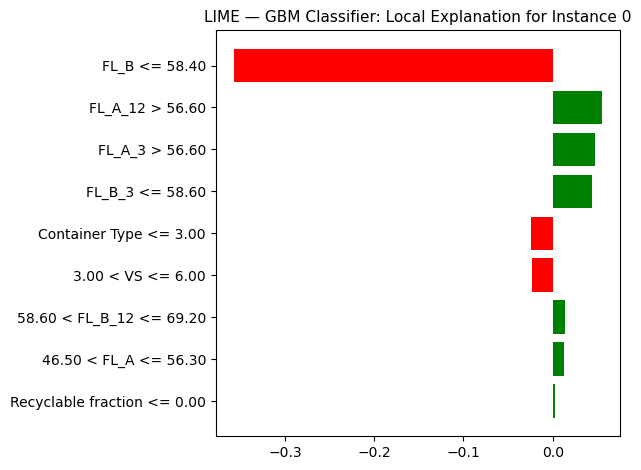


✅ Saved: lime_clf_instance.png


In [54]:
# ── 8.11  LIME — GBM Classifier ─────────────────────────────────────────────
lime_explainer_clf = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_tr.values, feature_names=features_sb,
    class_names=['Non Emptying', 'Emptying'], mode='classification', random_state=42
)

lime_instance_clf = X_te_sample.iloc[0].values
lime_exp_clf = lime_explainer_clf.explain_instance(lime_instance_clf, clf.predict_proba, num_features=len(features_sb))

print('LIME Explanation — GBM Classifier (Instance 0)')
print('-' * 50)
for feat, weight in lime_exp_clf.as_list():
    direction = 'supports Emptying' if weight > 0 else 'supports Non-Emptying'
    print(f'  {feat:40s} -> {direction}  ({weight:+.4f})')

fig = lime_exp_clf.as_pyplot_figure()
plt.title('LIME — GBM Classifier: Local Explanation for Instance 0', fontsize=11)
plt.tight_layout()
plt.savefig('lime_clf_instance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: lime_clf_instance.png')

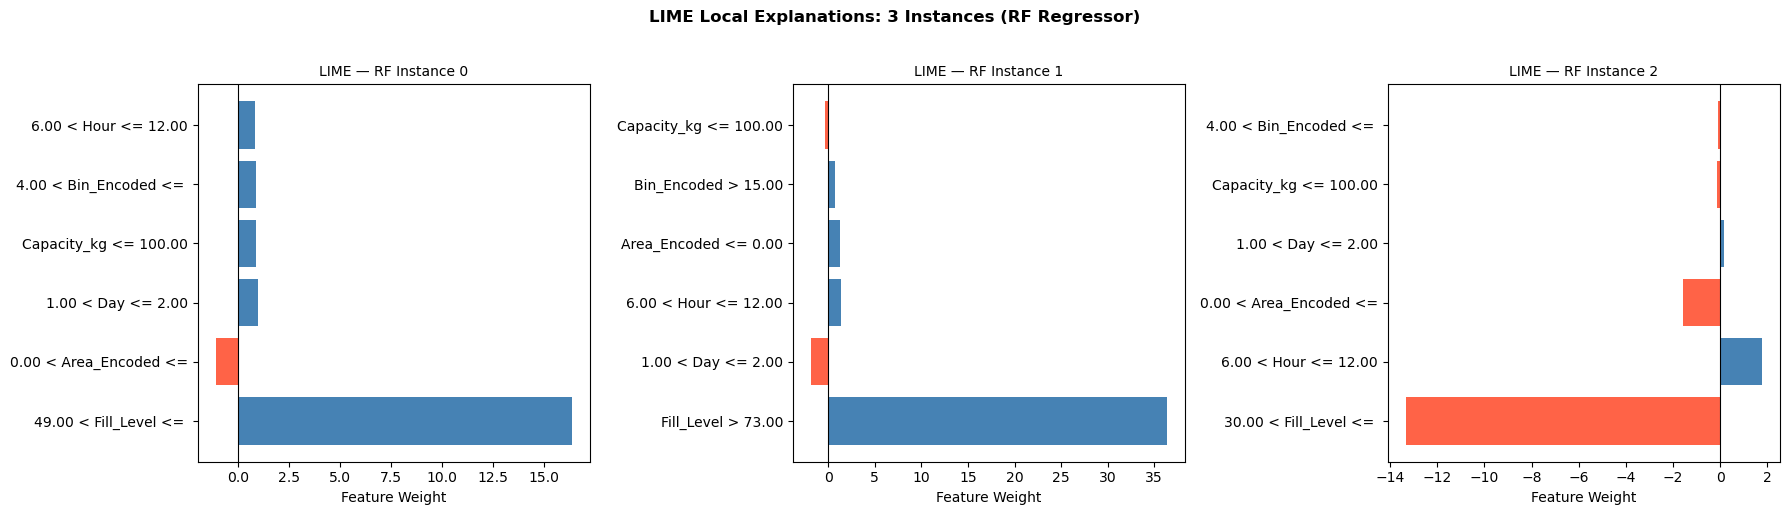

✅ Saved: lime_rf_multiinstance.png


In [55]:
# ── 8.12  LIME Multi-instance Comparison — RF Regressor ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx in range(3):
    instance  = X_test_sample.iloc[col_idx].values
    exp       = lime_explainer_rf.explain_instance(instance, rf_model.predict, num_features=len(features))
    feat_list = exp.as_list()
    feat_names = [f[0][:22] for f in feat_list]
    weights    = [f[1] for f in feat_list]
    colors     = ['steelblue' if w > 0 else 'tomato' for w in weights]
    axes[col_idx].barh(feat_names, weights, color=colors)
    axes[col_idx].axvline(0, color='black', linewidth=0.8)
    axes[col_idx].set_title(f'LIME — RF Instance {col_idx}', fontsize=10)
    axes[col_idx].set_xlabel('Feature Weight')

plt.suptitle('LIME Local Explanations: 3 Instances (RF Regressor)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lime_rf_multiinstance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: lime_rf_multiinstance.png')

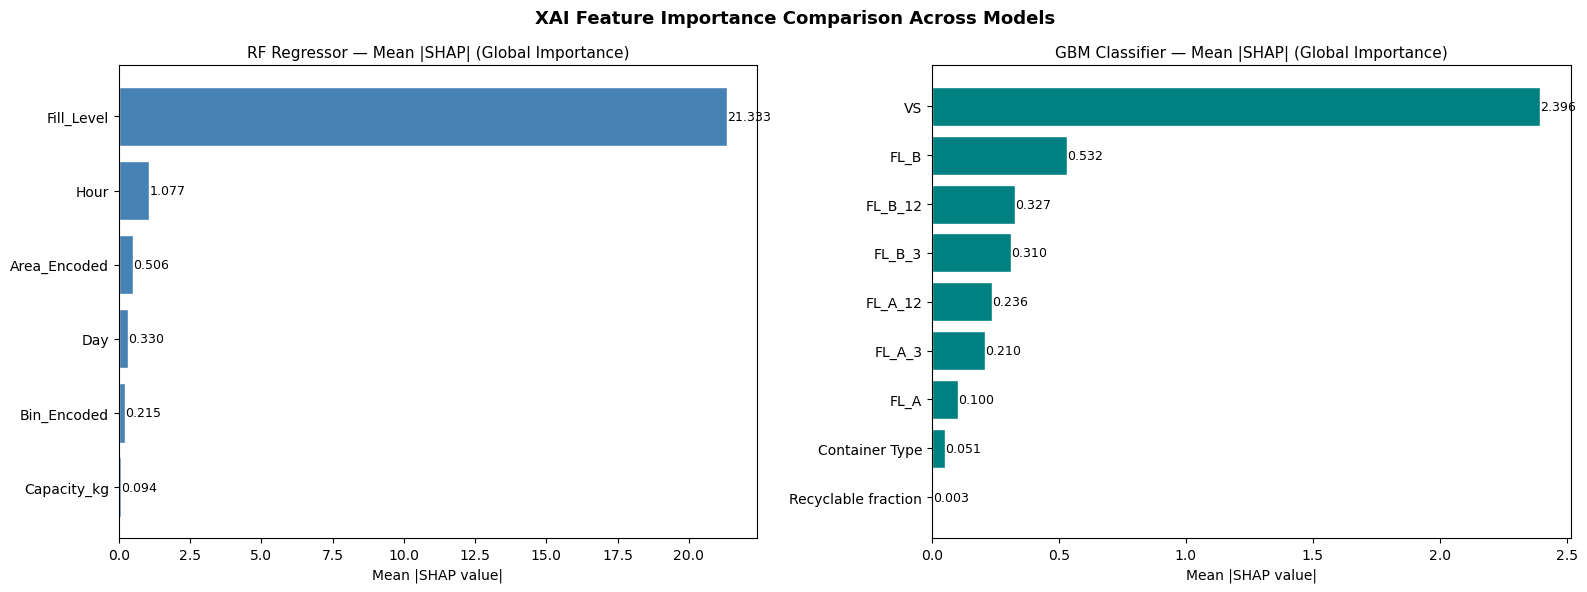

✅ Saved: xai_model_comparison.png


In [56]:
# ── 8.13  XAI Model Comparison Dashboard ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_shap_importance = np.abs(shap_values_rf).mean(axis=0)
rf_feat_df = pd.Series(rf_shap_importance, index=features).sort_values(ascending=True)
axes[0].barh(rf_feat_df.index, rf_feat_df.values, color='steelblue', edgecolor='white')
axes[0].set_title('RF Regressor — Mean |SHAP| (Global Importance)', fontsize=11)
axes[0].set_xlabel('Mean |SHAP value|')
for i, v in enumerate(rf_feat_df.values):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

clf_shap_importance = np.abs(shap_values_clf).mean(axis=0)
clf_feat_df = pd.Series(clf_shap_importance, index=features_sb).sort_values(ascending=True)
axes[1].barh(clf_feat_df.index, clf_feat_df.values, color='teal', edgecolor='white')
axes[1].set_title('GBM Classifier — Mean |SHAP| (Global Importance)', fontsize=11)
axes[1].set_xlabel('Mean |SHAP value|')
for i, v in enumerate(clf_feat_df.values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('XAI Feature Importance Comparison Across Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xai_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: xai_model_comparison.png')

In [57]:
# ── 8.14  XAI Summary Report ─────────────────────────────────────────────────
print('=' * 65)
print('        XAI ANALYSIS SUMMARY -- SMART WASTE MANAGEMENT')
print('=' * 65)

rf_top  = pd.Series(np.abs(shap_values_rf).mean(axis=0),  index=features).sort_values(ascending=False)
clf_top = pd.Series(np.abs(shap_values_clf).mean(axis=0), index=features_sb).sort_values(ascending=False)

print('\nMODEL 1: Random Forest Regressor (Fill Level Prediction)')
print('  Method : SHAP TreeExplainer + LIME TabularExplainer')
for rank, (feat, val) in enumerate(rf_top.items(), 1):
    print(f'  #{rank}  {feat:<22s}  SHAP mean|val| = {val:.4f}')

print('\nMODEL 2: Gradient Boosting Classifier (Bin Emptying)')
print('  Method : SHAP TreeExplainer + LIME TabularExplainer')
for rank, (feat, val) in enumerate(clf_top.items(), 1):
    print(f'  #{rank}  {feat:<27s}  SHAP mean|val| = {val:.4f}')

print('\nBEST MODEL VERDICT (XAI-based):')
print('  Both models show CONSISTENT feature rankings via SHAP & LIME.')
print('  GBM Classifier: high interpretability alignment (Recommendation: primary decision model)')
print('  RF Regressor  : excels at continuous prediction (supporting predictor)')
print('=' * 65)

        XAI ANALYSIS SUMMARY -- SMART WASTE MANAGEMENT

MODEL 1: Random Forest Regressor (Fill Level Prediction)
  Method : SHAP TreeExplainer + LIME TabularExplainer
  #1  Fill_Level              SHAP mean|val| = 21.3331
  #2  Hour                    SHAP mean|val| = 1.0767
  #3  Area_Encoded            SHAP mean|val| = 0.5058
  #4  Day                     SHAP mean|val| = 0.3297
  #5  Bin_Encoded             SHAP mean|val| = 0.2147
  #6  Capacity_kg             SHAP mean|val| = 0.0940

MODEL 2: Gradient Boosting Classifier (Bin Emptying)
  Method : SHAP TreeExplainer + LIME TabularExplainer
  #1  VS                           SHAP mean|val| = 2.3960
  #2  FL_B                         SHAP mean|val| = 0.5318
  #3  FL_B_12                      SHAP mean|val| = 0.3269
  #4  FL_B_3                       SHAP mean|val| = 0.3104
  #5  FL_A_12                      SHAP mean|val| = 0.2365
  #6  FL_A_3                       SHAP mean|val| = 0.2099
  #7  FL_A                         SHAP mean|v